This notebook is used to get the Experiment results for the dropclass-publication.
It proceeds work from `research_2_after_data_update.ipynb`

# Prerequisites

## Import Libs

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, AutoMinorLocator
import seaborn as sns

import pickle

sns.set_style('darkgrid')

from catboost import CatBoostClassifier

from sklearn.preprocessing import PolynomialFeatures

from statannotations.Annotator import Annotator

from scipy.stats import shapiro, chi2_contingency

## Functions

In [2]:
def plot_K_scatter(
    scatter_df:pd.DataFrame,
    impact_type_name:str,
    impact_type_df:pd.DataFrame,
    y_feature_name:str,
    y_label:str,
    ax:mpl.axes.Axes,
    markersize:int=15,
):
    # Plot scatters
    for i, row in impact_type_df.iterrows():
        impact_group = scatter_df[scatter_df[impact_type_name] == row['value']]
        
        ax.scatter(
            x=impact_group['K'],
            y=impact_group[y_feature_name],
            marker=row['marker'],
            s=markersize,
            color=row['color'],
            label=row['impact_type'],
        )
        
    #get handles and labels
    handles, labels = ax.get_legend_handles_labels()

    #specify order of items in legend
    order = impact_type_df['order'].values

    #add legend to plot
    ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order]) 

    ax.set_xlabel('$K$')

    ax.set_ylabel(y_label);
    
    return ax


def plot_K(
    contour_df:pd.DataFrame,
    scatter_df:pd.DataFrame,
    impact_type_name:str,
    impact_type_df:pd.DataFrame,
    y_feature_name:str,
    y_label:str,
    ax:mpl.axes.Axes,
    cmap_fill='coolwarm',
    cmap_contour='Greys',
    levels_fill=50,
    levels_contour=[0.3, 0.4, 0.5, 0.6, 0.7],
    markersize:int=15,
    fontsize:int=12,
):
    # Mesh Values
    x = contour_df['K'].unique()
    y = contour_df[y_feature_name].unique()
    probas = contour_df[impact_type_name].values.reshape(x.size, y.size) # TODO: Check, Maybe: .reshape(y.size, z.size)
    
    contourfplot = ax.contourf(
        x,
        y,
        probas,
        cmap=cmap_fill,
        levels=levels_fill,
        vmin=0.,
        vmax=1.,
        alpha=0.8,
        antialiased=True,
    )
    plt.colorbar(contourfplot, ax=ax)
    
    contplot = ax.contour(
        x,
        y,
        probas,
        cmap=cmap_contour,
        levels=levels_contour,
        vmin=0.,
        vmax=1.,
    )
    ax.clabel(contplot, fmt = '%1.1f', colors = 'k', fontsize=fontsize) #contour line labels
    
    ax = plot_K_scatter(
        scatter_df,
        impact_type_name,
        impact_type_df,
        y_feature_name,
        y_label,
        ax,
        markersize,
    )
    
    ax.grid(color='black', alpha=0.5)
    
    return ax

Prepare impact types

In [3]:
splash_impact_type_dt = {
    'impact_type': ['no splashing', 'splashing', 'semi splashing',],
    'value': [0, 2, 1,],
    'color': ['b', 'r', 'g',],
    'marker': ['x', 'o', 's',],
    'order': [0, 2, 1,] # legend order
}

splash_impact_type_df = pd.DataFrame(splash_impact_type_dt)
display(splash_impact_type_df)

no_fragmentation_type_dt = {
    'impact_type': ['fragmentation', 'no fragmentation'],
    'value': [0, 1],
    'color': ['r', 'b'],
    'marker': ['x', 'o'],
    'order': [0, 1] # legend order
}

no_fragmentation_type_df = pd.DataFrame(no_fragmentation_type_dt)
no_fragmentation_type_df

,impact_type,value,color,marker,order
0,no splashing,0,b,x,0
1,splashing,2,r,o,2
2,semi splashing,1,g,s,1


,impact_type,value,color,marker,order
0,fragmentation,0,r,x,0
1,no fragmentation,1,b,o,1


In [4]:
# import new main notebook
df_main = pd.read_excel('../data/df_main.xlsx')
display(df_main.head())
df_main.info()

,test,no_fragmentation,splashing,splashing_spectrum,breaking_up,rebound,one_drop,voltage,long_impulse_duration,long_impulse_dur_binary,...,sedimentation_velocity,sedimentation_Re,sedimentation_Stk,sign_sedimentation_Re,sign_sedimentation_Stk,sign_particle_droplet_diameter_ratio,droplet_density,free_fall_velocity,drag_velocity,relative_roughness
0,3,0,1,2,0,0,1,105.0,10,low,...,0.000018,0.000092,8.252778e-08,0.000092,8.252778e-08,0.013301,836.828587,3.961141,3.682513,0.000032
1,4,0,1,2,0,0,1,105.0,10,low,...,0.000018,0.000092,8.252778e-08,0.000092,8.252778e-08,0.013301,835.298244,3.961141,3.682027,0.000032
2,5,0,1,2,0,0,1,105.0,10,low,...,0.000018,0.000092,8.252778e-08,0.000092,8.252778e-08,0.013301,835.298244,3.961141,3.682027,0.000032
3,7,0,1,2,0,0,0,105.0,10,low,...,0.000018,0.000092,8.582889e-08,0.000092,8.582889e-08,0.013833,836.869874,3.961141,3.668435,0.000013
4,8,0,1,2,0,0,0,105.0,10,low,...,0.000018,0.000092,8.582889e-08,0.000092,8.582889e-08,0.013833,836.795029,3.961141,3.668410,0.000013


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 372 entries, 0 to 371
Data columns (total 42 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   test                                  372 non-null    int64  
 1   no_fragmentation                      372 non-null    int64  
 2   splashing                             372 non-null    int64  
 3   splashing_spectrum                    372 non-null    int64  
 4   breaking_up                           372 non-null    int64  
 5   rebound                               372 non-null    int64  
 6   one_drop                              372 non-null    int64  
 7   voltage                               372 non-null    float64
 8   long_impulse_duration                 372 non-null    int64  
 9   long_impulse_dur_binary               372 non-null    object 
 10  wettability                           372 non-null    object 
 11  roughness          

## Description

### Labels description:

- **splashing_spectrum**: 
    - **0 - no splashing**, when *'Number of detached small droplets during Spreading' == 0*
    - **1 - semi splashing**, when **gear** occurs, or when few droplets detach
    - **2 - splashing**. Pure splashing, when **many** droplets or **many small** droplets detach
    
- **splashing**: 1 - when *'Number of detached small droplets during Spreading' != 0*;
- **breaking_up**: when *'Number of detached small droplets during Receding or Rim merging' > 0*
- **rebound** consists of next cases:
    - **2 - true rebound**, when droplets detaching during partial rebound, or when droplet rebounds totally.
    
    *True rebound: 'Rebound' == 2 OR ('Rebound' == 1 AND 'Number of detached droplets during Rebound' > 0)*
    - **1 - jet ejection**, when true rebound does not appear.

    *'Rim merging or Central jet ejecting' == 2 AND NOT True rebound*    
    - **0** - no true rebound and no jet ejection. *Other cases*

- **no_fragmentation**: when there is 
    - **no Splashing** (no small droplets detached during spreading, *'Number of detached small droplets during Spreading'==0*), 
    - **no Breaking up** (when *'Number of detached small droplets during Receding or Rim merging' == 0*)
    - **no True Rebound** (see True rebound definition early)

### Physical properties

$velocity = \sqrt{2g\cdot height}$

$Re=\frac{velocity \cdot droplet\_diameter \cdot liquid\_density}{viscosity}$

$We=\frac{velocity^2 \cdot droplet\_diameter \cdot liquid\_density}{surface\_tension}$

$K = We^{1/2}Re^{1/4}$

particle_droplet_diameter_ratio = particle_mean_diameter / droplet_diameter

particle_liquid_density_ratio = particle_density / liquid_density

*Params above were checked*

## Data preparation

### Main column groups 

In [5]:
targets = ['no_fragmentation', 'splashing']
impact_labels = ['splashing_spectrum', 'breaking_up', 'rebound']

# Unnecesary to model
generation_features = [
    'one_drop', 'voltage', 'long_impulse_duration', 'long_impulse_dur_binary'
]

# do not forget 'test'
features_original = [
    'wettability', 'roughness', 'liquid_density', 'surface_tension', 
    'viscosity', 'particle_mean_diameter', 'particle_density', 
    'volume_fraction', 'droplet_diameter', 'height', 'inclination'
]

features_aggregated = [
    'roughness_binary', 'particle_liquid_density_ratio', 
    'volume_fraction_binary', 'particle_diameter_cat', 
    'particle_droplet_diameter_ratio', 
    'velocity', 'Re', 'We', 'K'
]

### Drop unnecessary features

In [6]:
features_to_drop = generation_features + [
    'height', # velocity is more informative
    # 'volume_fraction' # 0.04 and 0.05 are the same group of low volume fraction, as well as 0.08 and 0.10
]

df = df_main.drop(
    features_to_drop, 
    axis=1,
)
display(df.head())
df.info()

,test,no_fragmentation,splashing,splashing_spectrum,breaking_up,rebound,wettability,roughness,liquid_density,surface_tension,...,sedimentation_velocity,sedimentation_Re,sedimentation_Stk,sign_sedimentation_Re,sign_sedimentation_Stk,sign_particle_droplet_diameter_ratio,droplet_density,free_fall_velocity,drag_velocity,relative_roughness
0,3,0,1,2,0,0,lyophilic,0.10,820,0.0269,...,0.000018,0.000092,8.252778e-08,0.000092,8.252778e-08,0.013301,836.828587,3.961141,3.682513,0.000032
1,4,0,1,2,0,0,lyophilic,0.10,820,0.0269,...,0.000018,0.000092,8.252778e-08,0.000092,8.252778e-08,0.013301,835.298244,3.961141,3.682027,0.000032
2,5,0,1,2,0,0,lyophilic,0.10,820,0.0269,...,0.000018,0.000092,8.252778e-08,0.000092,8.252778e-08,0.013301,835.298244,3.961141,3.682027,0.000032
3,7,0,1,2,0,0,neutral,0.04,820,0.0269,...,0.000018,0.000092,8.582889e-08,0.000092,8.582889e-08,0.013833,836.869874,3.961141,3.668435,0.000013
4,8,0,1,2,0,0,neutral,0.04,820,0.0269,...,0.000018,0.000092,8.582889e-08,0.000092,8.582889e-08,0.013833,836.795029,3.961141,3.668410,0.000013


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 372 entries, 0 to 371
Data columns (total 37 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   test                                  372 non-null    int64  
 1   no_fragmentation                      372 non-null    int64  
 2   splashing                             372 non-null    int64  
 3   splashing_spectrum                    372 non-null    int64  
 4   breaking_up                           372 non-null    int64  
 5   rebound                               372 non-null    int64  
 6   wettability                           372 non-null    object 
 7   roughness                             372 non-null    float64
 8   liquid_density                        372 non-null    int64  
 9   surface_tension                       372 non-null    float64
 10  viscosity                             372 non-null    float64
 11  particle_mean_diame

## Prepare text definitions of the features

In [7]:
df['no_fragmentation_type'] = df['no_fragmentation'].map(
    no_fragmentation_type_df['impact_type'].to_dict()
)
df['no_fragmentation_type'].value_counts()

fragmentation       273
no fragmentation     99
Name: no_fragmentation_type, dtype: int64

In [8]:
# def get_splashing_type(value):
#     if value == 0:
#         return 'no splashing'
#     if value == 1:
#         return 'semi splashing'
#     else:
#         return 'splashing'

df['splashing_type'] = df['splashing_spectrum'].map(
    splash_impact_type_df
    .sort_values('value')['impact_type']
    .reset_index(drop=True)
    .to_dict()
)
df['splashing_type'].value_counts()

splashing         185
no splashing      132
semi splashing     55
Name: splashing_type, dtype: int64

In [9]:
def get_volume_fraction_type(value):
    if value == 1:
        return '0.08 .. 0.10'
    else:
        return '0.04 .. 0.05'

df['volume_fraction_type'] = df['volume_fraction_binary'].apply(get_volume_fraction_type)
df['volume_fraction_type'].value_counts()

0.08 .. 0.10    271
0.04 .. 0.05    101
Name: volume_fraction_type, dtype: int64

In [10]:
def get_rebound_type(value):
    if value == 1:
        return 'jet ejection'
    if value == 2:
        return 'rebound'
    else:
        return 'no'

df['rebound_type'] = df['rebound'].apply(get_rebound_type)
df['rebound_type'].value_counts()

no              272
jet ejection     54
rebound          46
Name: rebound_type, dtype: int64

In [11]:
def get_breaking_up_type(value):
    if value == 1:
        return 'yes'
    else:
        return 'no'

df['breaking_up_type'] = df['breaking_up'].apply(get_breaking_up_type)
df['breaking_up_type'].value_counts()

no     273
yes     99
Name: breaking_up_type, dtype: int64

# Research

## Splashing and No fragmentation

Let us plot different scatter-plots with Re_We at the bottom

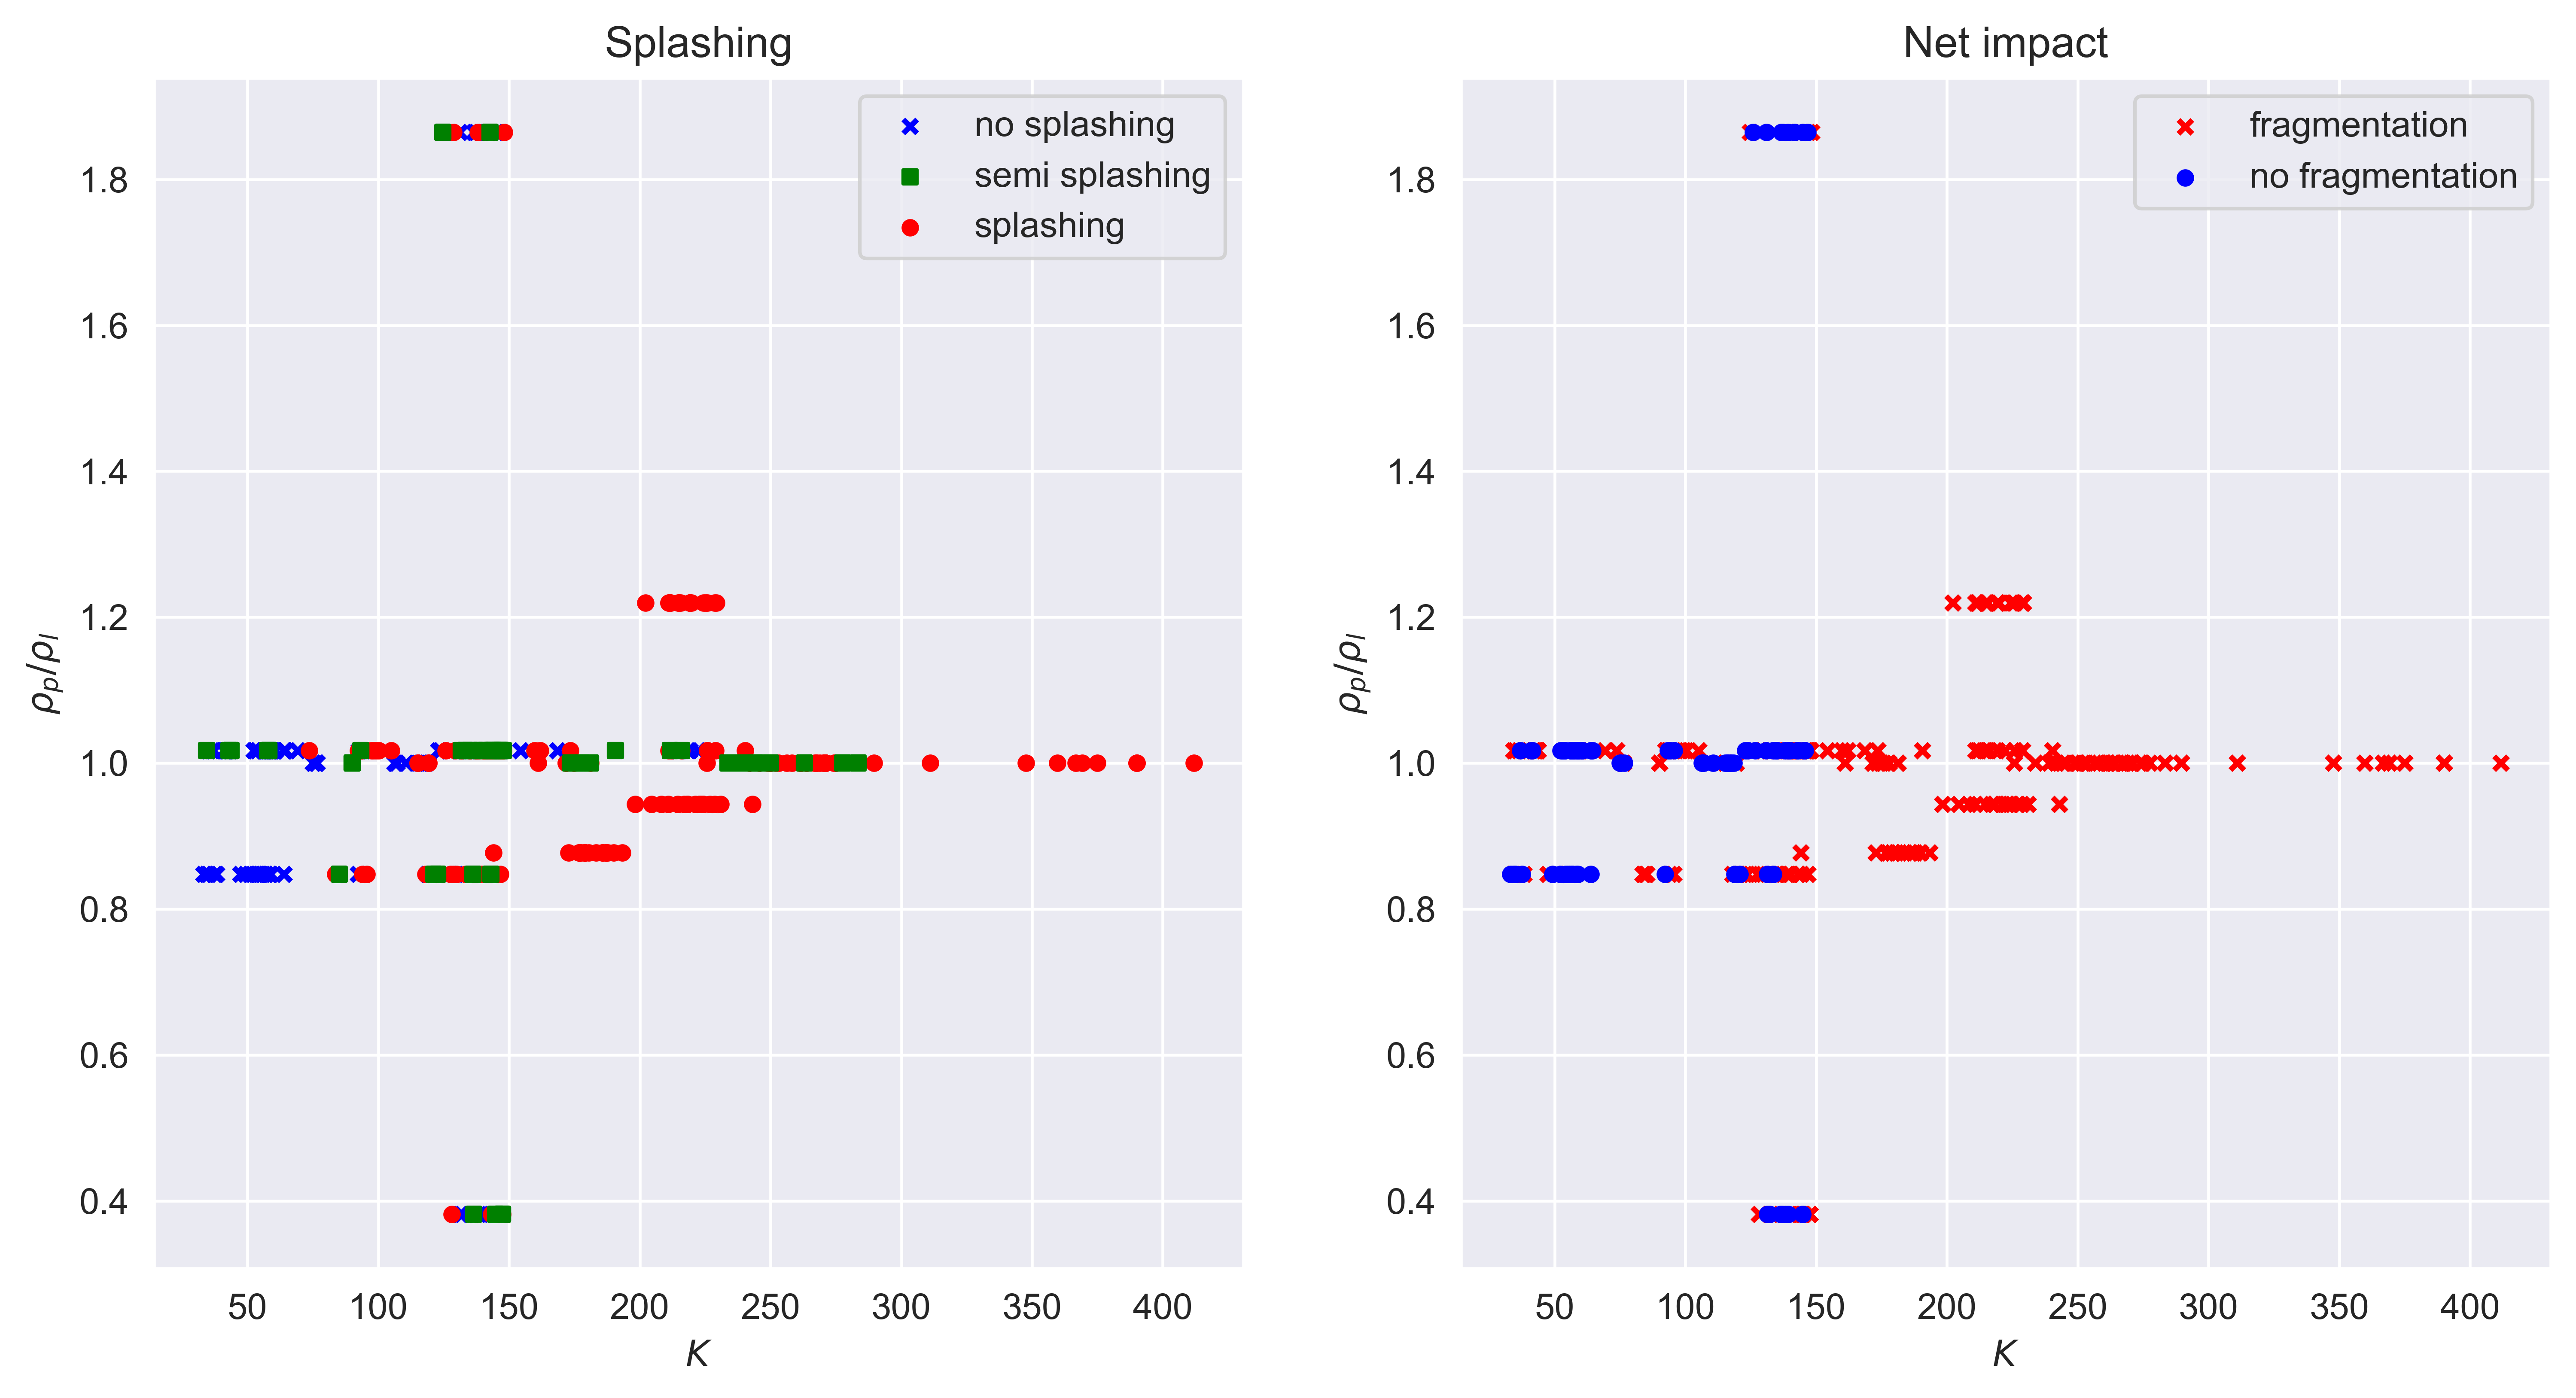

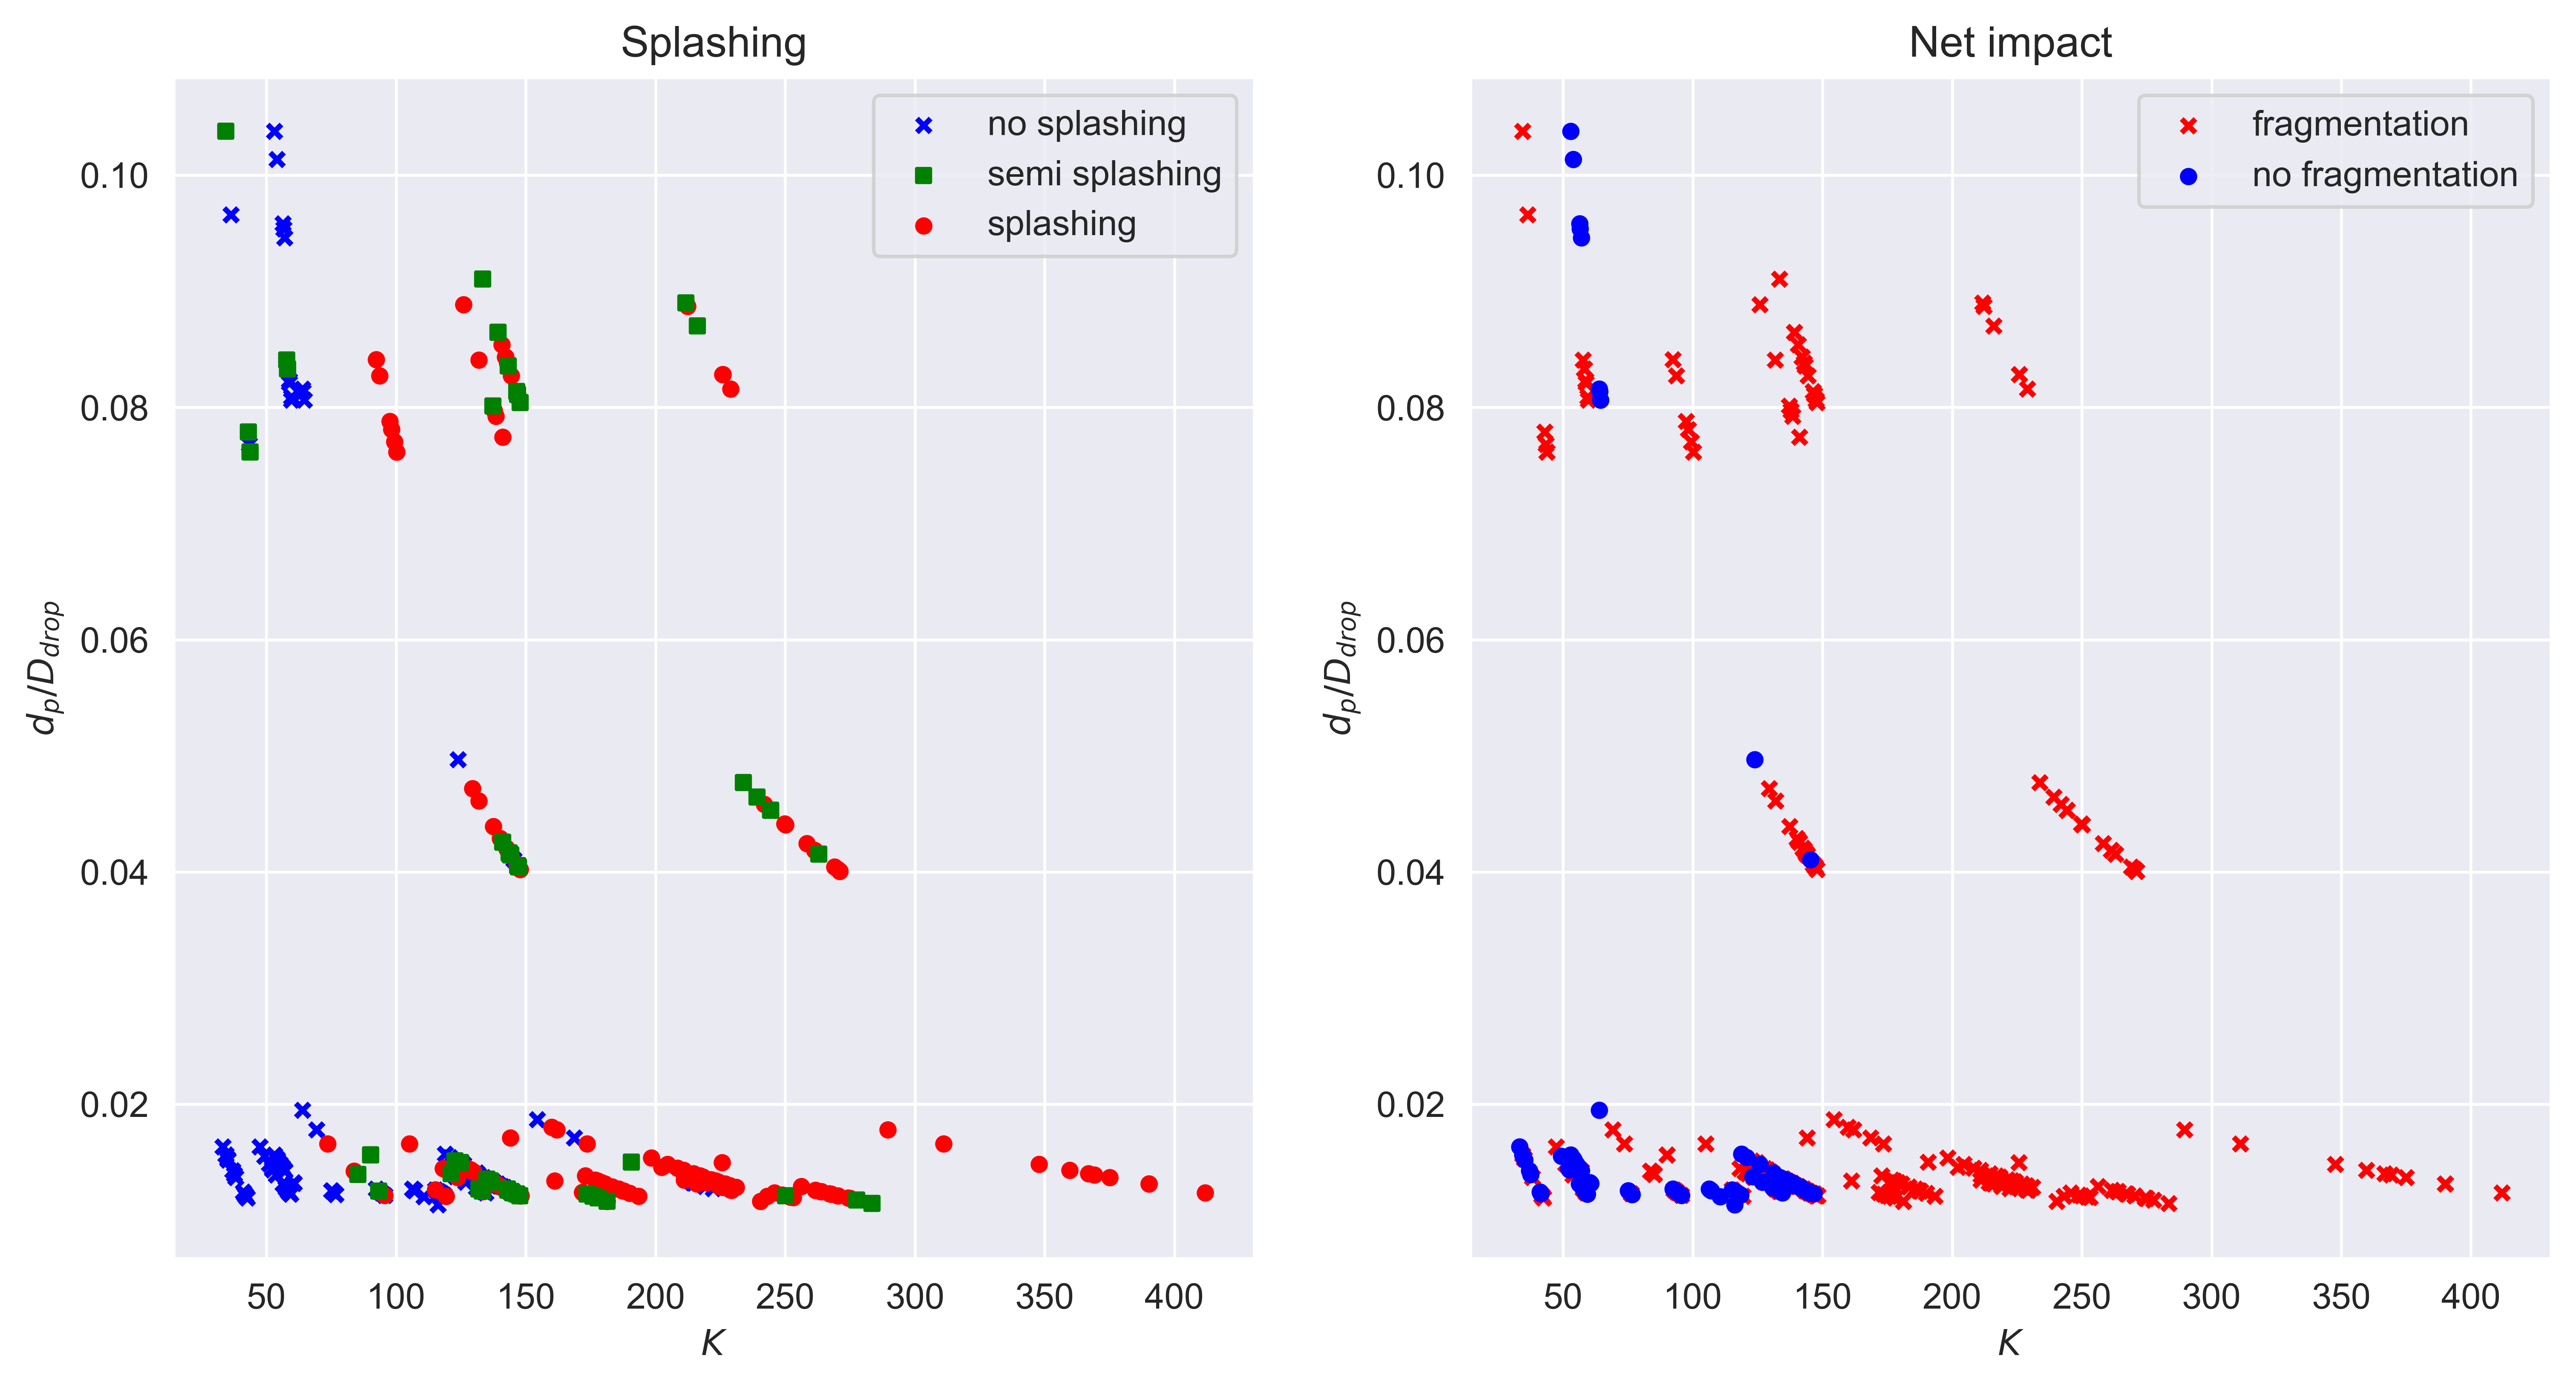

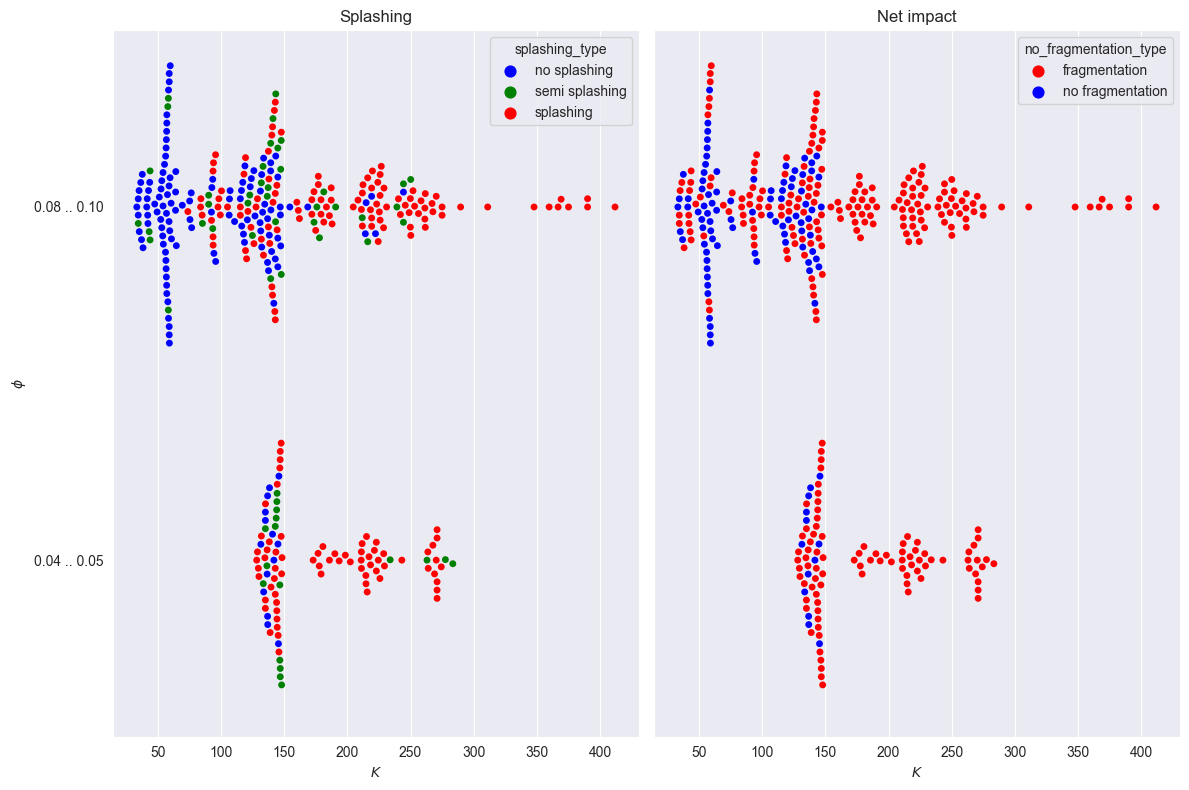

In [12]:
def plot_scatters(df):

    y_feature_name = 'particle_liquid_density_ratio'
    y_label = '$\\rho_{p}/\\rho_{l}$'

    fig, axes = plt.subplots(1, 2, figsize=(12, 6), dpi=600)

    plot_K_scatter(
        scatter_df=df,
        impact_type_name='splashing_spectrum',
        impact_type_df=splash_impact_type_df,
        y_feature_name=y_feature_name,
        y_label=y_label,
        ax=axes[0]
    )

    plot_K_scatter(
        scatter_df=df,
        impact_type_name='no_fragmentation',
        impact_type_df=no_fragmentation_type_df,
        y_feature_name=y_feature_name,
        y_label=y_label,
        ax=axes[1]
    );

    axes[0].set_title('Splashing');
    axes[1].set_title('Net impact');


    # PARTICLE DROPLET DIAMETER RATIO

    y_feature_name = 'particle_droplet_diameter_ratio'
    y_label = '$d_p/D_{drop}$'

    fig, axes = plt.subplots(1, 2, figsize=(12, 6), dpi=600)

    plot_K_scatter(
        scatter_df=df,
        impact_type_name='splashing_spectrum',
        impact_type_df=splash_impact_type_df,
        y_feature_name=y_feature_name,
        y_label=y_label,
        ax=axes[0]
    )

    plot_K_scatter(
        scatter_df=df,
        impact_type_name='no_fragmentation',
        impact_type_df=no_fragmentation_type_df,
        y_feature_name=y_feature_name,
        y_label=y_label,
        ax=axes[1]
    );

    axes[0].set_title('Splashing');
    axes[1].set_title('Net impact');

    # PHI-PLOT

    sns.color_palette('Set2')

    fig, (ax_splash, ax_no_fragmentation) = plt.subplots(1, 2, figsize=(12,8))

    sns.swarmplot(
    data=df, 
    x='K', 
    y='volume_fraction_type', 
    hue='splashing_type', # style='splashing_type', 
    ax=ax_splash, 
    orient='h', 
    size=4.95, 
    order=['0.08 .. 0.10', '0.04 .. 0.05'],
    hue_order=['no splashing', 'semi splashing', 'splashing'],
    palette=list(splash_impact_type_df.sort_values('value')['color'].values)
    )

    sns.swarmplot(
    data=df, 
    x='K', 
    y='volume_fraction_type', 
    hue='no_fragmentation_type', # style='splashing_type', 
    ax=ax_no_fragmentation, 
    orient='h', 
    size=4.95, 
    order=['0.08 .. 0.10', '0.04 .. 0.05'],
    palette=list(no_fragmentation_type_df['color'].values)

    )

    axes = (ax_splash, ax_no_fragmentation)

    for ax in axes:
        # ax.set_xticks(list(np.arange(0, 510, 50)));
        ax.set_xlabel('$K$')

    ax_no_fragmentation.get_yaxis().set_visible(False)
    ax_splash.set_ylabel('$\phi$');

    ax_splash.set_title('Splashing');
    ax_no_fragmentation.set_title('Net impact');

    fig.tight_layout()
    
plot_scatters(df)

## Particle-liquid density ratio influence on splashing

no splashing vs. semi splashing: Mann-Whitney-Wilcoxon test two-sided, P_val:4.110e-01 U_stat=3.665e+02
semi splashing vs. splashing: Mann-Whitney-Wilcoxon test two-sided, P_val:2.198e-01 U_stat=5.470e+02
no splashing vs. splashing: Mann-Whitney-Wilcoxon test two-sided, P_val:1.476e-01 U_stat=1.082e+03


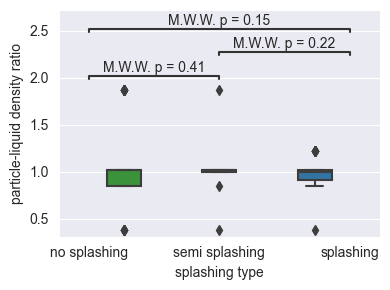

In [13]:
order = ['no splashing', 'semi splashing', 'splashing']

y_feature = 'particle_liquid_density_ratio'

inclination_mask = df['inclination'] == 0
wet_mask = df['wettability'] == 'lyophilic'

sub_df = df[
    inclination_mask
    & wet_mask
]

fig, ax = plt.subplots(figsize=(4,3))
sns.boxplot(
    data=sub_df, 
    x='splashing_type', y=y_feature, 
    order=order, 
    hue='splashing_type',
    # flierprops={"marker": "x"},
    ax=ax
)

pairs = [
    ('no splashing', 'semi splashing'),
    ('semi splashing', 'splashing'),
    ('no splashing', 'splashing')  
]

annotator = Annotator(ax, pairs, data=sub_df, x='splashing_type', 
        y=y_feature, order=order)
annotator.configure(test='Mann-Whitney', text_format='simple', loc='inside')
annotator.apply_and_annotate()

ax.set_ylabel('particle-liquid density ratio')
ax.set_xlabel('splashing type');
ax.get_legend().remove()
fig.tight_layout()

# fig.savefig('../results/experiments/splashing_K.pdf')

## Particle-droplet diameter rario influence on splashing

no splashing vs. semi splashing: Mann-Whitney-Wilcoxon test two-sided, P_val:2.701e-02 U_stat=2.030e+02
semi splashing vs. splashing: Mann-Whitney-Wilcoxon test two-sided, P_val:2.826e-02 U_stat=6.200e+02
no splashing vs. splashing: Mann-Whitney-Wilcoxon test two-sided, P_val:4.353e-01 U_stat=8.270e+02


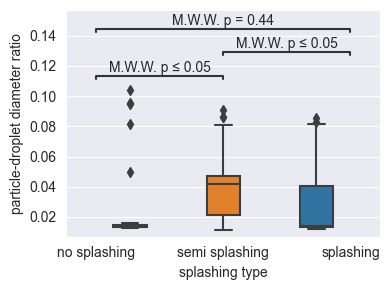

In [14]:
order = ['no splashing', 'semi splashing', 'splashing']

y_feature = 'particle_droplet_diameter_ratio'

inclination_mask = df['inclination'] == 0
wet_mask = df['wettability'] == 'lyophilic'


sub_df = df[
    inclination_mask
    & wet_mask
]


fig, ax = plt.subplots(figsize=(4,3))
sns.boxplot(
    data=sub_df, 
    x='splashing_type', y=y_feature, 
    order=order, 
    hue='splashing_type',
    # flierprops={"marker": "x"},
    ax=ax
)

pairs = [
    ('no splashing', 'semi splashing'),
    ('semi splashing', 'splashing'),
    ('no splashing', 'splashing')  
]

annotator = Annotator(ax, pairs, data=sub_df, x='splashing_type', 
        y=y_feature, order=order)
annotator.configure(test='Mann-Whitney', text_format='simple', loc='inside')
annotator.apply_and_annotate()

ax.set_ylabel('particle-droplet diameter ratio')
ax.set_xlabel('splashing type');
ax.get_legend().remove()
fig.tight_layout()

# fig.savefig('../results/experiments/splashing_K.pdf')

In [15]:
sub_df.groupby(
    by='splashing_type'
)['particle_droplet_diameter_ratio'].median()

splashing_type
no splashing      0.013431
semi splashing    0.041604
splashing         0.013833
Name: particle_droplet_diameter_ratio, dtype: float64

<Axes: xlabel='K', ylabel='particle_droplet_diameter_ratio'>

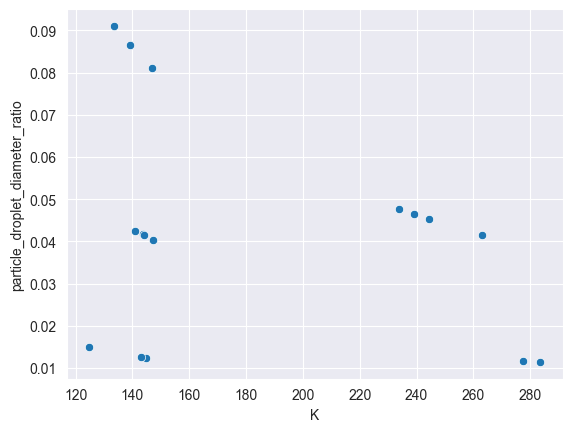

In [16]:
sns.scatterplot(
    data=sub_df[sub_df['splashing_spectrum']==1],
    y=y_feature,
    x='K'
)

## Volume fraction influence on splashing

In [17]:
df.pivot_table(
    values="Re",
    index='volume_fraction_type',
    columns='splashing_type',
    aggfunc='count'
)

splashing_type,no splashing,semi splashing,splashing
volume_fraction_type,,,
0.04 .. 0.05,14,17,70
0.08 .. 0.10,118,38,115


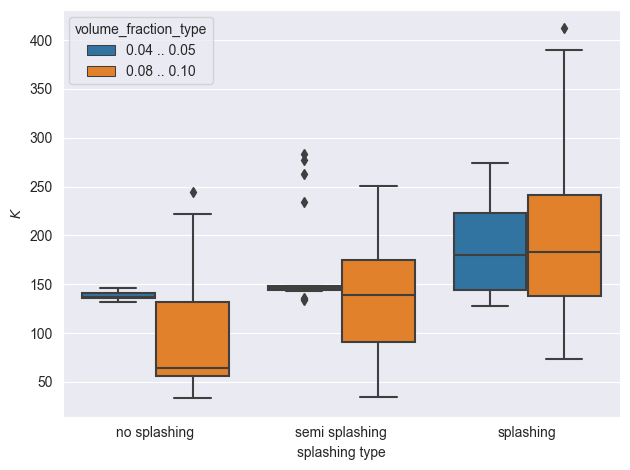

In [18]:
fig, ax = plt.subplots()
sns.boxplot(
    data=df, 
    x='splashing_type', y='K', 
    order=['no splashing', 'semi splashing', 'splashing'], 
    hue='volume_fraction_type',
    hue_order=['0.04 .. 0.05', '0.08 .. 0.10'],
    # flierprops={"marker": "x"},
    ax=ax
)
ax.set_ylabel('$K$')
ax.set_xlabel('splashing type');
fig.tight_layout()

In [19]:
df['particle_density'].value_counts()

1000    183
1200    147
450      23
2200     19
Name: particle_density, dtype: int64

In [20]:
df['wettability'].value_counts()

lyophilic    147
neutral      114
lyophobic    111
Name: wettability, dtype: int64

0.04 .. 0.05 vs. 0.08 .. 0.10: Mann-Whitney-Wilcoxon test two-sided, P_val:1.487e-01 U_stat=3.000e+01


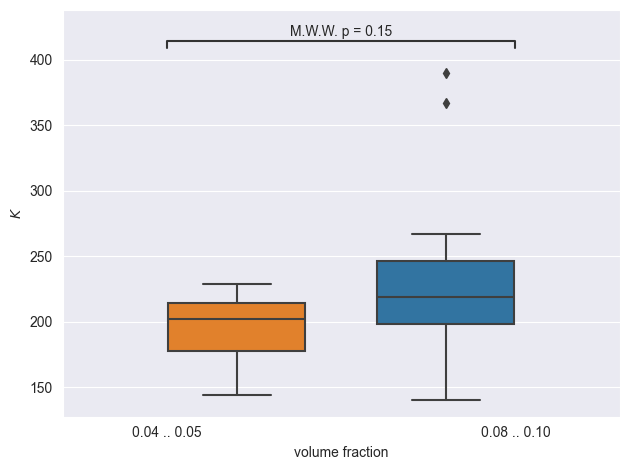

In [21]:
feature = 'volume_fraction_type'
order = ['0.04 .. 0.05', '0.08 .. 0.10']

df_splashing = df[
    (df['splashing_type'] == 'splashing')
    & (df['inclination'] == 0)
    & (df['wettability'] == 'lyophilic')
    & (df['roughness'] == 0.10)
    & (df['particle_diameter_cat'] == 'small')
    & (df['particle_density'] == 1000)
]

fig, ax = plt.subplots()
sns.boxplot(
    data=df_splashing, 
    x=feature, y='K', 
    order=order,
    hue=feature,
    # flierprops={"marker": "x"},
    ax=ax
)

pairs = [
    ('0.04 .. 0.05', '0.08 .. 0.10'),
]

annotator = Annotator(ax, pairs, data=df_splashing, x=feature, 
        y='K', order=order)
annotator.configure(test='Mann-Whitney', text_format='simple', loc='inside')
annotator.apply_and_annotate()

ax.set_ylabel('$K$')
ax.set_xlabel('volume fraction');
ax.get_legend().remove()
fig.tight_layout()

# fig.savefig('../results/experiments/breaking_up_K.pdf')

0.04 .. 0.05 vs. 0.08 .. 0.10: Mann-Whitney-Wilcoxon test two-sided, P_val:3.333e-01 U_stat=4.000e+00


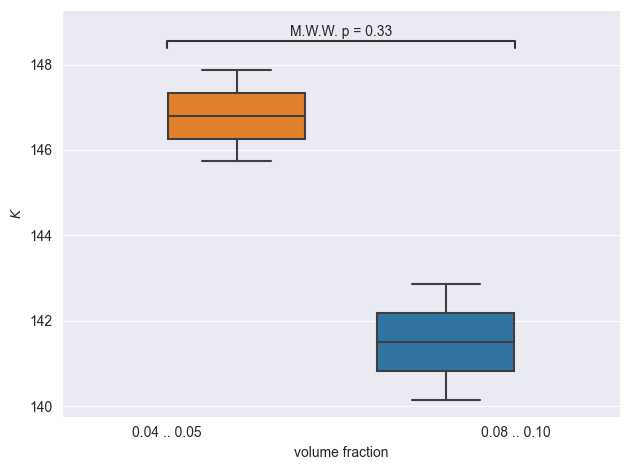

In [22]:
feature = 'volume_fraction_type'
order = ['0.04 .. 0.05', '0.08 .. 0.10']

df_splashing = df[
    (df['splashing_type'] == 'splashing')
    & (df['inclination'] == 0)
    & (df['wettability'] == 'neutral')
    # & (df['roughness'] == 0.10)
    # & (df['particle_diameter_cat'] == 'small')
    & (df['particle_density'] == 1200)
]

fig, ax = plt.subplots()
sns.boxplot(
    data=df_splashing, 
    x=feature, y='K', 
    order=order,
    hue=feature,
    # flierprops={"marker": "x"},
    ax=ax
)

pairs = [
    ('0.04 .. 0.05', '0.08 .. 0.10'),
]

annotator = Annotator(ax, pairs, data=df_splashing, x=feature, 
        y='K', order=order)
annotator.configure(test='Mann-Whitney', text_format='simple', loc='inside')
annotator.apply_and_annotate()

ax.set_ylabel('$K$')
ax.set_xlabel('volume fraction');
ax.get_legend().remove()
fig.tight_layout()

# fig.savefig('../results/experiments/breaking_up_K.pdf')

0.08 .. 0.10 vs. 0.04 .. 0.05: Mann-Whitney-Wilcoxon test two-sided, P_val:4.813e-02 U_stat=2.140e+02


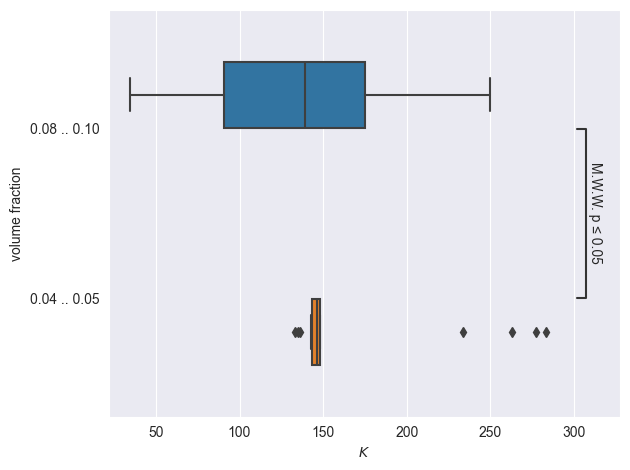

In [23]:
feature = 'volume_fraction_type'
order = ['0.08 .. 0.10', '0.04 .. 0.05']

df_splashing = df[
    (df['splashing_spectrum'] == 1)
    # & (df['inclination'] == 0)
    # & (df['wettability'] == 'lyophilic')
    # # & (df['roughness'] == 0.10)
    # & (df['particle_diameter_cat'] == 'small')
    # # & (df['particle_density'] == 1200)
]

fig, ax = plt.subplots()
sns.boxplot(
    data=df_splashing, 
    y=feature, x='K', 
    order=order,
    hue=feature,
    # flierprops={"marker": "x"},
    ax=ax
)

pairs = [
    ('0.04 .. 0.05', '0.08 .. 0.10'),
]

annotator = Annotator(ax, pairs, data=df_splashing, y=feature, 
        x='K', order=order, orient='h')
annotator.configure(test='Mann-Whitney', text_format='simple', loc='inside',)
annotator.apply_and_annotate()

ax.set_xlabel('$K$')
ax.set_ylabel('volume fraction');
ax.get_legend().remove()
fig.tight_layout()

# fig.savefig('../results/experiments/breaking_up_K.pdf')

0.08 .. 0.10 vs. 0.04 .. 0.05: Mann-Whitney-Wilcoxon test two-sided, P_val:1.853e-01 U_stat=2.500e+01


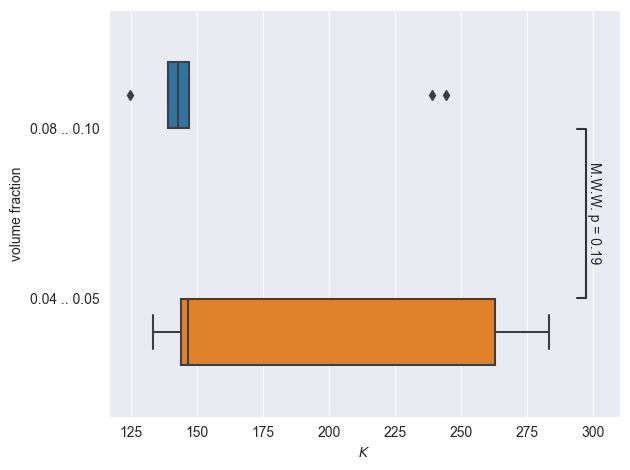

In [24]:
feature = 'volume_fraction_type'
order = ['0.08 .. 0.10', '0.04 .. 0.05']

df_splashing = df[
    (df['splashing_spectrum'] == 1)
    & (df['inclination'] == 0)
    & (df['wettability'] == 'lyophilic')
    # # & (df['roughness'] == 0.10)
    # & (df['particle_diameter_cat'] == 'small')
    # # & (df['particle_density'] == 1200)
]

fig, ax = plt.subplots()
sns.boxplot(
    data=df_splashing, 
    y=feature, x='K', 
    order=order,
    hue=feature,
    # flierprops={"marker": "x"},
    ax=ax
)

pairs = [
    ('0.04 .. 0.05', '0.08 .. 0.10'),
]

annotator = Annotator(ax, pairs, data=df_splashing, y=feature, 
        x='K', order=order, orient='h')
annotator.configure(test='Mann-Whitney', text_format='simple', loc='inside',)
annotator.apply_and_annotate()

ax.set_xlabel('$K$')
ax.set_ylabel('volume fraction');
ax.get_legend().remove()
fig.tight_layout()

# fig.savefig('../results/experiments/breaking_up_K.pdf')

0.08 .. 0.10 vs. 0.04 .. 0.05: Mann-Whitney-Wilcoxon test two-sided, P_val:2.000e-01 U_stat=0.000e+00


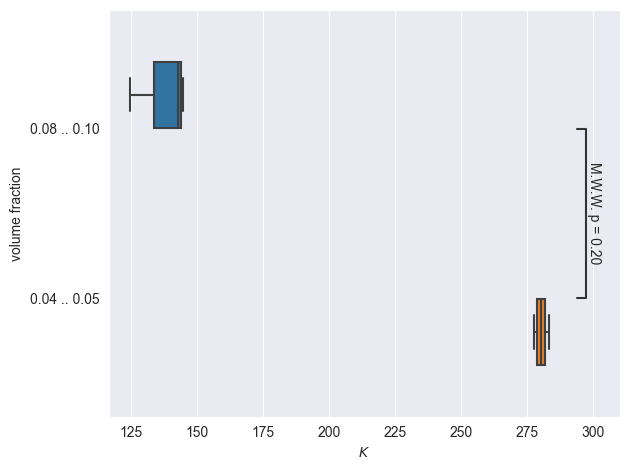

In [25]:
feature = 'volume_fraction_type'
order = ['0.08 .. 0.10', '0.04 .. 0.05']

df_splashing = df[
    (df['splashing_spectrum'] == 1)
    & (df['inclination'] == 0)
    & (df['wettability'] == 'lyophilic')
    # & (df['roughness'] == 0.10)
    & (df['particle_diameter_cat'] == 'small')
    # & (df['particle_density'] == 1200)
]

fig, ax = plt.subplots()
sns.boxplot(
    data=df_splashing, 
    y=feature, x='K', 
    order=order,
    hue=feature,
    # flierprops={"marker": "x"},
    ax=ax
)

pairs = [
    ('0.04 .. 0.05', '0.08 .. 0.10'),
]

annotator = Annotator(ax, pairs, data=df_splashing, y=feature, 
        x='K', order=order, orient='h')
annotator.configure(test='Mann-Whitney', text_format='simple', loc='inside',)
annotator.apply_and_annotate()

ax.set_xlabel('$K$')
ax.set_ylabel('volume fraction');
ax.get_legend().remove()
fig.tight_layout()

# fig.savefig('../results/experiments/breaking_up_K.pdf')

0.08 .. 0.10 vs. 0.04 .. 0.05: Mann-Whitney-Wilcoxon test two-sided, P_val:6.286e-01 U_stat=8.000e+00


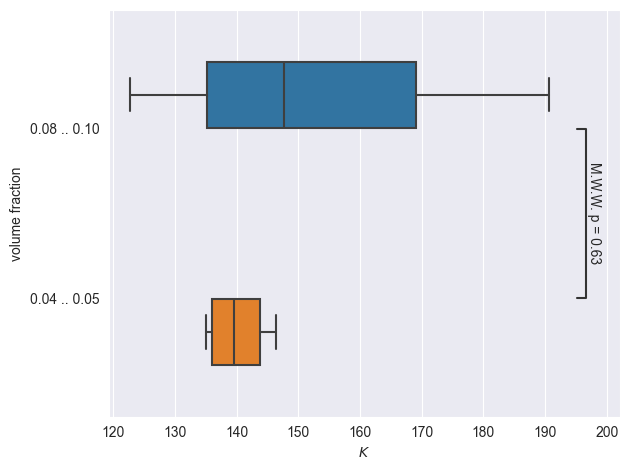

In [26]:
feature = 'volume_fraction_type'
order = ['0.08 .. 0.10', '0.04 .. 0.05']

df_splashing = df[
    (df['splashing_spectrum'] == 1)
    & (df['inclination'] == 0)
    & (df['wettability'] == 'neutral')
    # & (df['roughness'] == 0.10)
    & (df['particle_diameter_cat'] == 'small')
    # & (df['particle_density'] == 1200)
]

fig, ax = plt.subplots()
sns.boxplot(
    data=df_splashing, 
    y=feature, x='K', 
    order=order,
    hue=feature,
    # flierprops={"marker": "x"},
    ax=ax
)

pairs = [
    ('0.04 .. 0.05', '0.08 .. 0.10'),
]

annotator = Annotator(ax, pairs, data=df_splashing, y=feature, 
        x='K', order=order, orient='h')
annotator.configure(test='Mann-Whitney', text_format='simple', loc='inside',)
annotator.apply_and_annotate()

ax.set_xlabel('$K$')
ax.set_ylabel('volume fraction');
ax.get_legend().remove()
fig.tight_layout()

# fig.savefig('../results/experiments/breaking_up_K.pdf')

0.08 .. 0.10 vs. 0.04 .. 0.05: Mann-Whitney-Wilcoxon test two-sided, P_val:1.000e+00 U_stat=2.000e+00


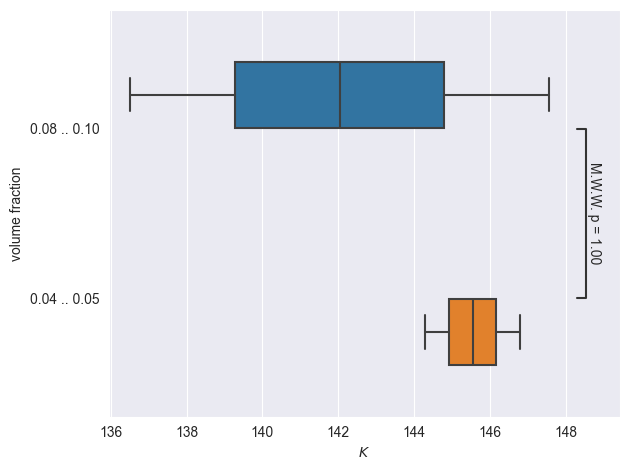

In [27]:
feature = 'volume_fraction_type'
order = ['0.08 .. 0.10', '0.04 .. 0.05']

df_splashing = df[
    (df['splashing_spectrum'] == 1)
    & (df['inclination'] == 0)
    & (df['wettability'] == 'lyophobic')
    # & (df['roughness'] == 0.10)
    # & (df['particle_diameter_cat'] == 'small')
    # & (df['particle_density'] == 1200)
]

fig, ax = plt.subplots()
sns.boxplot(
    data=df_splashing, 
    y=feature, x='K', 
    order=order,
    hue=feature,
    # flierprops={"marker": "x"},
    ax=ax
)

pairs = [
    ('0.04 .. 0.05', '0.08 .. 0.10'),
]

annotator = Annotator(ax, pairs, data=df_splashing, y=feature, 
        x='K', order=order, orient='h')
annotator.configure(test='Mann-Whitney', text_format='simple', loc='inside',)
annotator.apply_and_annotate()

ax.set_xlabel('$K$')
ax.set_ylabel('volume fraction');
ax.get_legend().remove()
fig.tight_layout()

# fig.savefig('../results/experiments/breaking_up_K.pdf')

~~Looks like less volume fraction - less variance in K.~~

However, no statistical significant difference were obtained.
Necessary to conduct more experiments.

Let us plot without phi differentiation

NOTE: NECESSARY TO COMPARE WITH MEAN VALUE BETWEEN NON-SPLASHING AND SPLASHING

## Roughness influence on splashing

0.1 vs. 10.89: Mann-Whitney-Wilcoxon test two-sided, P_val:8.683e-01 U_stat=1.350e+02


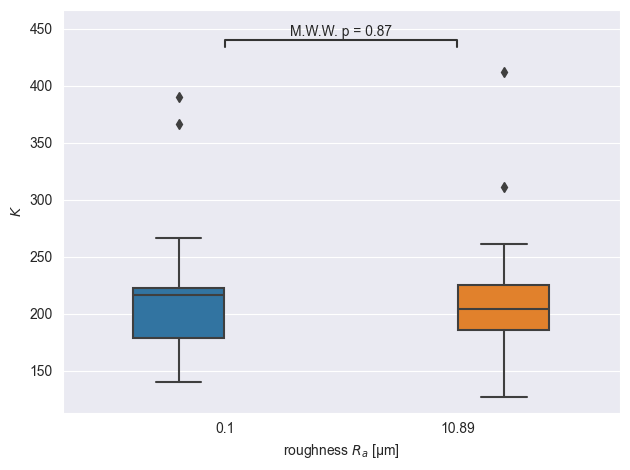

In [28]:
feature = 'roughness'
order = [0.10, 10.89]

df_splashing = df[
    (df['splashing_type'] == 'splashing')
    & (df['inclination'] == 0)
    & (df['wettability'] == 'lyophilic')
    # & (df['roughness'] == 0.10)
    & (df['particle_diameter_cat'] == 'small')
    & (df['particle_density'] == 1000)
]

fig, ax = plt.subplots()
sns.boxplot(
    data=df_splashing, 
    x=feature, y='K', 
    order=order, 
    hue=feature,
    # flierprops={"marker": "x"},
    ax=ax
)

pairs = [
    (0.10, 10.89),
]

annotator = Annotator(ax, pairs, data=df_splashing, x=feature, 
        y='K', order=order)
annotator.configure(test='Mann-Whitney', text_format='simple', loc='inside')
annotator.apply_and_annotate()

ax.set_ylabel('$K$')
ax.set_xlabel('roughness $R_a$ [µm]');
ax.get_legend().remove()
fig.tight_layout()


Let us consider only one inclination, but any other properties

0.1 vs. 10.89: Mann-Whitney-Wilcoxon test two-sided, P_val:2.578e-01 U_stat=3.790e+02


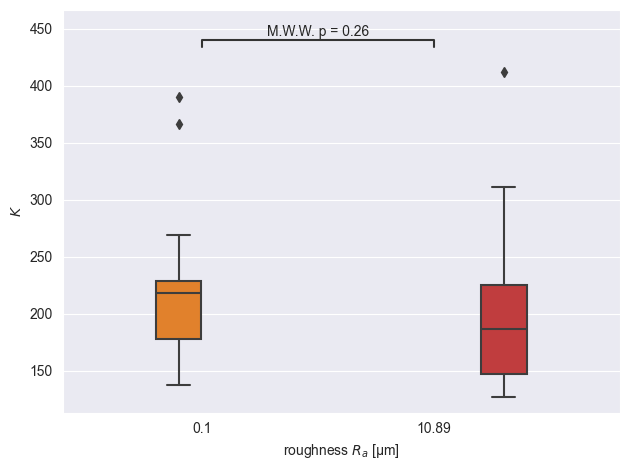

In [29]:
feature = 'roughness'
order = [0.10, 10.89]

df_splashing = df[
    (df['splashing_type'] == 'splashing')
    & (df['inclination'] == 0)
]

fig, ax = plt.subplots()
sns.boxplot(
    data=df_splashing, 
    x=feature, y='K', 
    order=order, 
    hue=feature,
    # flierprops={"marker": "x"},
    ax=ax
)

pairs = [
    (0.10, 10.89),
]

annotator = Annotator(ax, pairs, data=df_splashing, x=feature, 
        y='K', order=order)
annotator.configure(test='Mann-Whitney', text_format='simple', loc='inside')
annotator.apply_and_annotate()

ax.set_ylabel('$K$')
ax.set_xlabel('roughness $R_a$ [µm]');
ax.get_legend().remove()
fig.tight_layout()


Thus, we have not found statistical significant influence of roughness on splashing.
Necessary to conduct more experiments.

In [30]:
df

,test,no_fragmentation,splashing,splashing_spectrum,breaking_up,rebound,wettability,roughness,liquid_density,surface_tension,...,sign_particle_droplet_diameter_ratio,droplet_density,free_fall_velocity,drag_velocity,relative_roughness,no_fragmentation_type,splashing_type,volume_fraction_type,rebound_type,breaking_up_type
0,3,0,1,2,0,0,lyophilic,0.10,820,0.0269,...,0.013301,836.828587,3.961141,3.682513,0.000032,fragmentation,splashing,0.08 .. 0.10,no,no
1,4,0,1,2,0,0,lyophilic,0.10,820,0.0269,...,0.013301,835.298244,3.961141,3.682027,0.000032,fragmentation,splashing,0.08 .. 0.10,no,no
2,5,0,1,2,0,0,lyophilic,0.10,820,0.0269,...,0.013301,835.298244,3.961141,3.682027,0.000032,fragmentation,splashing,0.08 .. 0.10,no,no
3,7,0,1,2,0,0,neutral,0.04,820,0.0269,...,0.013833,836.869874,3.961141,3.668435,0.000013,fragmentation,splashing,0.08 .. 0.10,no,no
4,8,0,1,2,0,0,neutral,0.04,820,0.0269,...,0.013833,836.795029,3.961141,3.668410,0.000013,fragmentation,splashing,0.08 .. 0.10,no,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
367,391,0,0,0,0,2,lyophobic,2.49,1180,0.0679,...,0.082335,1182.252227,1.980571,1.950940,0.000746,fragmentation,no splashing,0.08 .. 0.10,rebound,no
368,392,0,1,1,0,0,lyophilic,0.10,1180,0.0679,...,0.083333,1182.325495,1.980571,1.950448,0.000030,fragmentation,semi splashing,0.08 .. 0.10,no,no
369,393,0,1,1,0,0,lyophilic,0.10,1180,0.0679,...,0.084098,1182.980827,1.980571,1.950085,0.000031,fragmentation,semi splashing,0.08 .. 0.10,no,no
370,394,0,0,0,1,0,neutral,0.04,1180,0.0679,...,0.082090,1182.143664,1.980571,1.951058,0.000012,fragmentation,no splashing,0.08 .. 0.10,no,yes


Let us get datasets with equal number of tests (OLD). Now no need for this

In [31]:
# # Get dataset with equal number of tests
# min_count = df['splashing_type'].value_counts().min()
# groups_idx = df.groupby(by='splashing_type').groups

# indexes = []

# for key in groups_idx:
#     indexes.extend(groups_idx[key][:min_count])
    
# df_stat_splash = df.iloc[indexes, :]

Before conducting tests let us check distribution

p=0.0000
Non-normal distribution for K


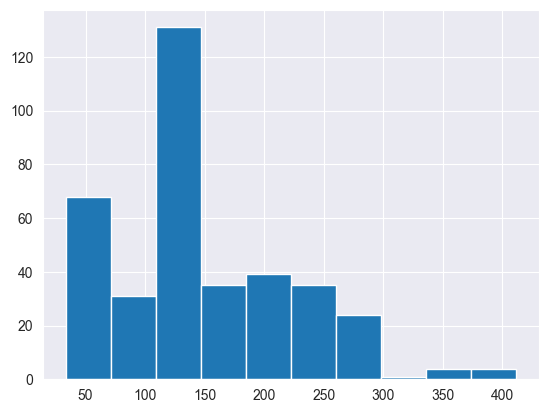

In [32]:
df['K'].hist()

feature = "K"

# Hypothesis
H0 = f'Normal distribution for {feature}'
Ha = f'Non-normal distribution for {feature}'

# Set significance level
alpha = 0.05

p_value = shapiro(df[feature])[1]
print(f'p={p_value:.4f}')

# Interpetation
if p_value > alpha:
  print(H0)
else:
  print(Ha)

- According to histogram, as well as to Shapiro test, we can not say, that feature is normally distributed;
- Comparison conducted for independent samples

So, let us use **Mann-Whitney-Wilcoxon** (U-test; Wilcoxon rank-sum test) for the paired samples

no splashing vs. semi splashing: Mann-Whitney-Wilcoxon test two-sided, P_val:1.349e-08 U_stat=1.714e+03
semi splashing vs. splashing: Mann-Whitney-Wilcoxon test two-sided, P_val:2.313e-04 U_stat=3.422e+03
no splashing vs. splashing: Mann-Whitney-Wilcoxon test two-sided, P_val:4.906e-31 U_stat=2.890e+03


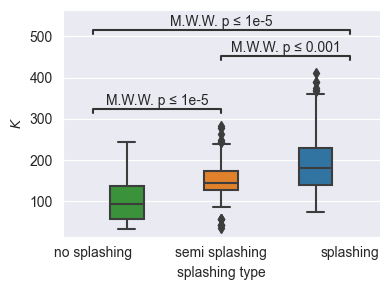

In [33]:
order = ['no splashing', 'semi splashing', 'splashing']

fig, ax = plt.subplots(figsize=(4,3))
sns.boxplot(
    data=df, 
    x='splashing_type', y='K', 
    order=order, 
    hue='splashing_type',
    # flierprops={"marker": "x"},
    ax=ax
)

pairs = [
    ('no splashing', 'semi splashing'),
    ('semi splashing', 'splashing'),
    ('no splashing', 'splashing')  
]

annotator = Annotator(ax, pairs, data=df, x='splashing_type', 
        y='K', order=order)
annotator.configure(test='Mann-Whitney', text_format='simple', loc='inside')
annotator.apply_and_annotate()

ax.set_ylabel('$K$')
ax.set_xlabel('splashing type');
ax.get_legend().remove()
fig.tight_layout()

# fig.savefig('../results/experiments/splashing_K.pdf')

### Check outliers


In [34]:

def get_outliers(series:pd.Series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    median = series.median()
    
    IQR = Q3 - Q1
    
    outliers_tuple = (Q1 - 1.5*IQR, Q3 + 1.5*IQR)
    
    return outliers_tuple

K_high_outlier = get_outliers(df[df['splashing'] == 0]['K'])[1]
print(f'K high outlier boundary: {K_high_outlier:.2f}')
df[(df['splashing'] == 0) & (df['K'] >= K_high_outlier)]

K high outlier boundary: 256.32


,test,no_fragmentation,splashing,splashing_spectrum,breaking_up,rebound,wettability,roughness,liquid_density,surface_tension,...,sign_particle_droplet_diameter_ratio,droplet_density,free_fall_velocity,drag_velocity,relative_roughness,no_fragmentation_type,splashing_type,volume_fraction_type,rebound_type,breaking_up_type


No outliers for "no splashing"

## Rebound

In [35]:
# # Get dataset with equal number of tests
# min_count = df['rebound_type'].value_counts().min()
# groups_idx = df.groupby(by='rebound_type').groups

# indexes = []

# for key in groups_idx:
#     indexes.extend(groups_idx[key][:min_count])
    
# df_stat_rebound = df.iloc[indexes, :]

In [36]:
df['rebound_type'].value_counts()

no              272
jet ejection     54
rebound          46
Name: rebound_type, dtype: int64

no vs. jet ejection: Mann-Whitney-Wilcoxon test two-sided, P_val:8.120e-01 U_stat=7.193e+03
jet ejection vs. rebound: Mann-Whitney-Wilcoxon test two-sided, P_val:4.935e-01 U_stat=1.342e+03
no vs. rebound: Mann-Whitney-Wilcoxon test two-sided, P_val:8.055e-01 U_stat=6.398e+03


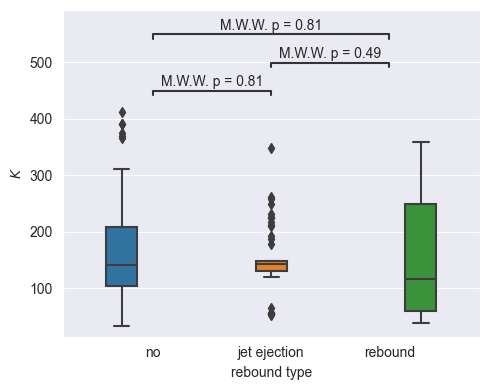

In [37]:
order = ['no', 'jet ejection', 'rebound']

feature = 'rebound_type'

fig, ax = plt.subplots(figsize=(5,4))
sns.boxplot(
    data=df, 
    x=feature, y='K', 
    order=order, 
    hue=feature,
    # flierprops={"marker": "x"},
    ax=ax
)

pairs = [
    ('no', 'jet ejection'),
    ('jet ejection', 'rebound'),
    ('no', 'rebound')  
]

annotator = Annotator(ax, pairs, data=df, x=feature, 
        y='K', order=order)
annotator.configure(test='Mann-Whitney', text_format='simple', loc='inside')
annotator.apply_and_annotate()

ax.set_ylabel('$K$')
ax.set_xlabel('rebound type');
ax.get_legend().remove()
fig.tight_layout()

# fig.savefig('../results/experiments/rebound_K.pdf')

No sufficient difference

## Breaking up

no vs. yes: Mann-Whitney-Wilcoxon test two-sided, P_val:2.015e-05 U_stat=9.606e+03


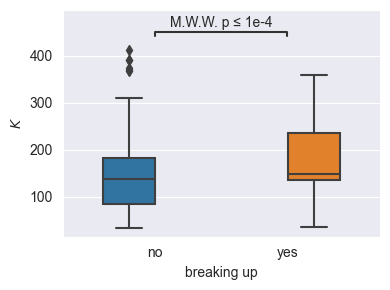

In [38]:
order = ['no', 'yes']

feature = 'breaking_up_type'

fig, ax = plt.subplots(figsize=(4,3))
sns.boxplot(
    data=df, 
    x=feature, y='K', 
    order=order, 
    hue=feature,
    # flierprops={"marker": "x"},
    ax=ax
)

pairs = [
    ('no', 'yes'),
]

annotator = Annotator(ax, pairs, data=df, x=feature, 
        y='K', order=order)
annotator.configure(test='Mann-Whitney', text_format='simple', loc='inside')
annotator.apply_and_annotate()

ax.set_ylabel('$K$')
ax.set_xlabel('breaking up');
ax.get_legend().remove()
fig.tight_layout()

# fig.savefig('../results/experiments/breaking_up_K.pdf')

## Chi-squared test

### Volume fraction

In [39]:
mask_wet = df['wettability'] == 'lyophilic'
mask_inclination = df['inclination'] == 0
mask_part_diam = df['particle_diameter_cat'] == 'large'

sub_df = df

cont_table = pd.crosstab(
    sub_df['volume_fraction_binary'],
    sub_df['splashing_spectrum']
)

display(cont_table)

stat, p, dot, exprcted = chi2_contingency(cont_table)

print("p-value = {:g}".format(p))

splashing_spectrum,0,1,2
volume_fraction_binary,,,
0,14,17,70
1,118,38,115


p-value = 4.24777e-07


In [40]:
mask_wet = df['wettability'] == 'lyophilic'
mask_inclination = df['inclination'] == 0
mask_part_diam = df['particle_diameter_cat'] == 'large'

sub_df = df[
    mask_wet
    & mask_inclination
    # & mask_part_diam
]

cont_table = pd.crosstab(
    sub_df['volume_fraction_binary'],
    sub_df['splashing_spectrum']
)

display(cont_table)

stat, p, dot, exprcted = chi2_contingency(cont_table)

print("p-value = {:g}".format(p))

splashing_spectrum,0,1,2
volume_fraction_binary,,,
0,11,9,17
1,25,9,34


p-value = 0.342021


In [41]:
mask_wet = df['wettability'] == 'neutral'
mask_inclination = df['inclination'] == 0
mask_part_diam = df['particle_diameter_cat'] == 'small'
mask_liquid_density = df['liquid_density'] == 1180
mask_height = df_main['height'] == 0.8

sub_df = df[
    mask_wet
    & mask_inclination
    # & mask_part_diam
    # & mask_liquid_density
    # & mask_height
]

cont_table = pd.crosstab(
    sub_df['volume_fraction_binary'],
    sub_df['splashing']
)

display(cont_table)

stat, p, dot, exprcted = chi2_contingency(cont_table)

print("p-value = {:g}".format(p))

splashing,0,1
volume_fraction_binary,,
0,3,27
1,25,22


p-value = 0.000319112


In [42]:
mask_wet = df['wettability'] == 'neutral'
mask_inclination = df['inclination'] == 0
mask_part_diam = df['particle_diameter_cat'] == 'small'
mask_liquid_density = df['liquid_density'] == 1180
mask_height = df_main['height'] == 0.8

sub_df = df[
    mask_wet
    & mask_inclination
    # & mask_part_diam
    & mask_liquid_density
    & mask_height
]

cont_table = pd.crosstab(
    sub_df['volume_fraction_binary'],
    sub_df['splashing']
)

display(cont_table)

stat, p, dot, exprcted = chi2_contingency(cont_table)

print("p-value = {:g}".format(p))

splashing,0,1
volume_fraction_binary,,
0,3,10
1,9,5


p-value = 0.0774679


In [43]:
mask_wet = df['wettability'] == 'lyophobic'
mask_inclination = df['inclination'] == 0
mask_part_diam = df['particle_diameter_cat'] == 'small'
# mask_liquid_density = df['liquid_density'] == 1180
mask_height = df_main['height'] == 0.8

sub_df = df[
    mask_wet
    & mask_inclination
    # & mask_part_diam
    # & mask_liquid_density
    & mask_height
]

cont_table = pd.crosstab(
    sub_df['volume_fraction_binary'],
    sub_df['splashing']
)

display(cont_table)

stat, p, dot, exprcted = chi2_contingency(cont_table)

print("p-value = {:g}".format(p))

splashing,0,1
volume_fraction_binary,,
0,0,34
1,3,21


p-value = 0.12974


Check volume fraction influence on diameter

0.04 .. 0.05 vs. 0.08 .. 0.10: Mann-Whitney-Wilcoxon test two-sided, P_val:2.375e-01 U_stat=1.478e+04


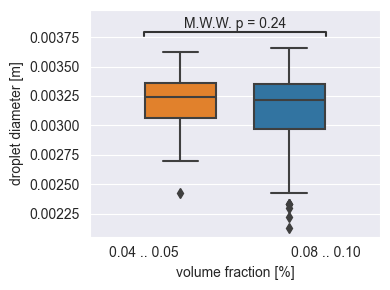

In [44]:
order = ['0.04 .. 0.05', '0.08 .. 0.10']

feature = 'volume_fraction_type'
y_feature = 'droplet_diameter'

fig, ax = plt.subplots(figsize=(4,3))
sns.boxplot(
    data=df, 
    x=feature, y=y_feature, 
    order=order, 
    hue=feature,
    # flierprops={"marker": "x"},
    ax=ax
)

pairs = [
    ('0.04 .. 0.05', '0.08 .. 0.10'),
]

annotator = Annotator(ax, pairs, data=df, x=feature, 
        y=y_feature, order=order)
annotator.configure(test='Mann-Whitney', text_format='simple', loc='inside')
annotator.apply_and_annotate()

ax.set_ylabel('droplet diameter [m]')
ax.set_xlabel('volume fraction [%]');
ax.get_legend().remove()
fig.tight_layout()

There is no statistical significant influence of the volume fraction on droplet diameter

### Roughness

In [45]:
mask_wet = df['wettability'] == 'lyophilic'
mask_inclination = df['inclination'] == 0
# mask_part_diam = df['particle_diameter_cat'] == 'large'

sub_df = df[
    mask_wet
    & mask_inclination
    # & mask_part_diam
]

cont_table = pd.crosstab(
    sub_df['roughness_binary'],
    sub_df['splashing_spectrum']
)

display(cont_table)

stat, p, dot, exprcted = chi2_contingency(cont_table)

print("p-value = {:g}".format(p))

splashing_spectrum,0,1,2
roughness_binary,,,
0,27,15,29
1,9,3,22


p-value = 0.0601865


No statistical significance

## Glycerol data

Let us set horisontal lyophillic smooth substrate (inclination = 0; wettability = 'lyophillic', roughness = 0.1).

Also, let us consider water-glycerol solution (liquid_density = 1180; viscosity = 0.0231; surface_tension = 0.0679),
and droplets with some median diameter (droplet_diameter = 0.00318).

Let us consider 8-10% suspension concentration (volume_fraction_binary = 1).

We will vary both (in two plots) **particle_mean_diameter** (in range 0.0000415...0.000275) and **particle_liquid_density_ratio** (in range 0.38 .. 1.86) - for y-axis.

Also we will vary droplet **velocity** in range (1.98 .. 5.94) to get different K values for x-axis.

Let us consider the statistics of the selected experiments:

In [46]:
wet_mask = df['wettability'] == 'lyophilic'
roughness_mask = df['roughness'] == 0.1
inclination_mask = df['inclination'] == 0
density_mask = df['liquid_density'] == 1180

glycerol_mask = wet_mask & roughness_mask & inclination_mask & density_mask

glycerol_df = df[glycerol_mask]
display(glycerol_df.describe().T)
display(glycerol_df.describe(include='object').T)

,count,mean,std,min,25%,50%,75%,max
test,43.0,1.834651e+02,9.041606e+01,5.000000e+01,1.135000e+02,1.720000e+02,2.360000e+02,360.000000
no_fragmentation,43.0,5.581395e-01,5.024855e-01,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000
splashing,43.0,3.953488e-01,4.947118e-01,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000
splashing_spectrum,43.0,5.813953e-01,7.938021e-01,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,2.000000
breaking_up,43.0,4.651163e-02,2.130826e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000
rebound,43.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
roughness,43.0,1.000000e-01,2.808406e-17,1.000000e-01,1.000000e-01,1.000000e-01,1.000000e-01,0.100000
liquid_density,43.0,1.180000e+03,0.000000e+00,1.180000e+03,1.180000e+03,1.180000e+03,1.180000e+03,1180.000000
surface_tension,43.0,6.790000e-02,1.404203e-17,6.790000e-02,6.790000e-02,6.790000e-02,6.790000e-02,0.067900
viscosity,43.0,2.310000e-02,0.000000e+00,2.310000e-02,2.310000e-02,2.310000e-02,2.310000e-02,0.023100


,count,unique,top,freq
wettability,43,1,lyophilic,43
particle_diameter_cat,43,3,small,27
no_fragmentation_type,43,2,no fragmentation,24
splashing_type,43,3,no splashing,26
volume_fraction_type,43,2,0.08 .. 0.10,27
rebound_type,43,1,no,43
breaking_up_type,43,2,no,41


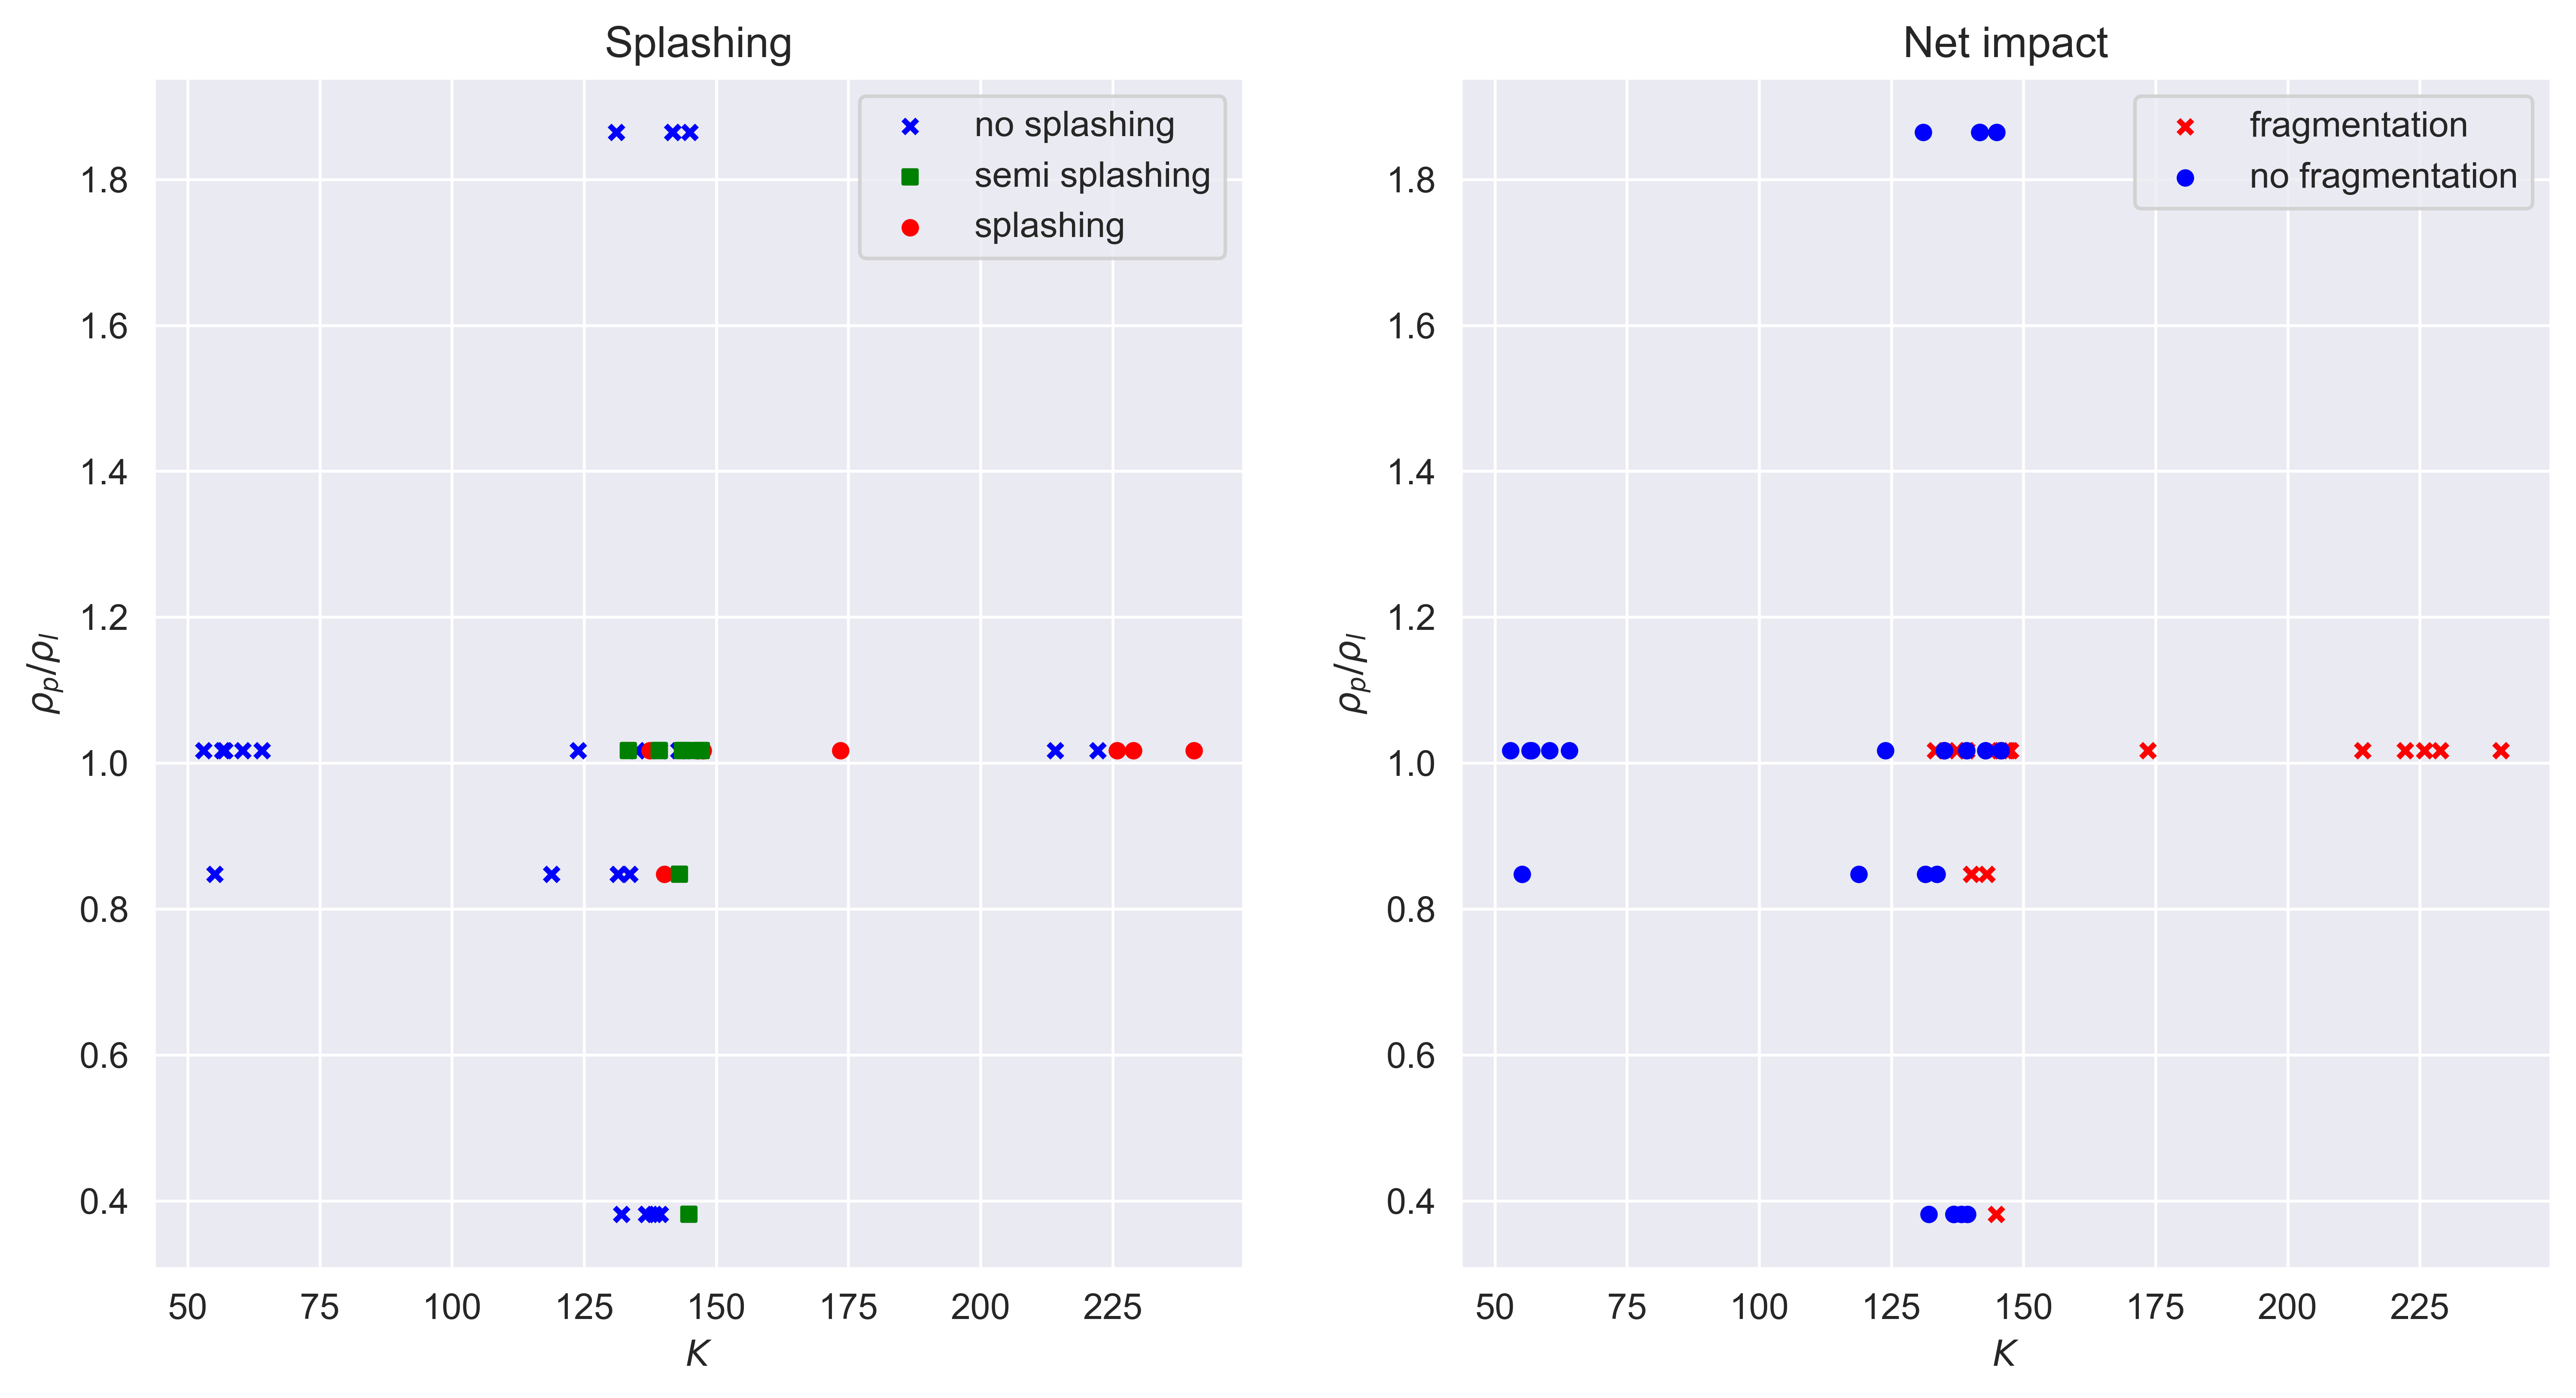

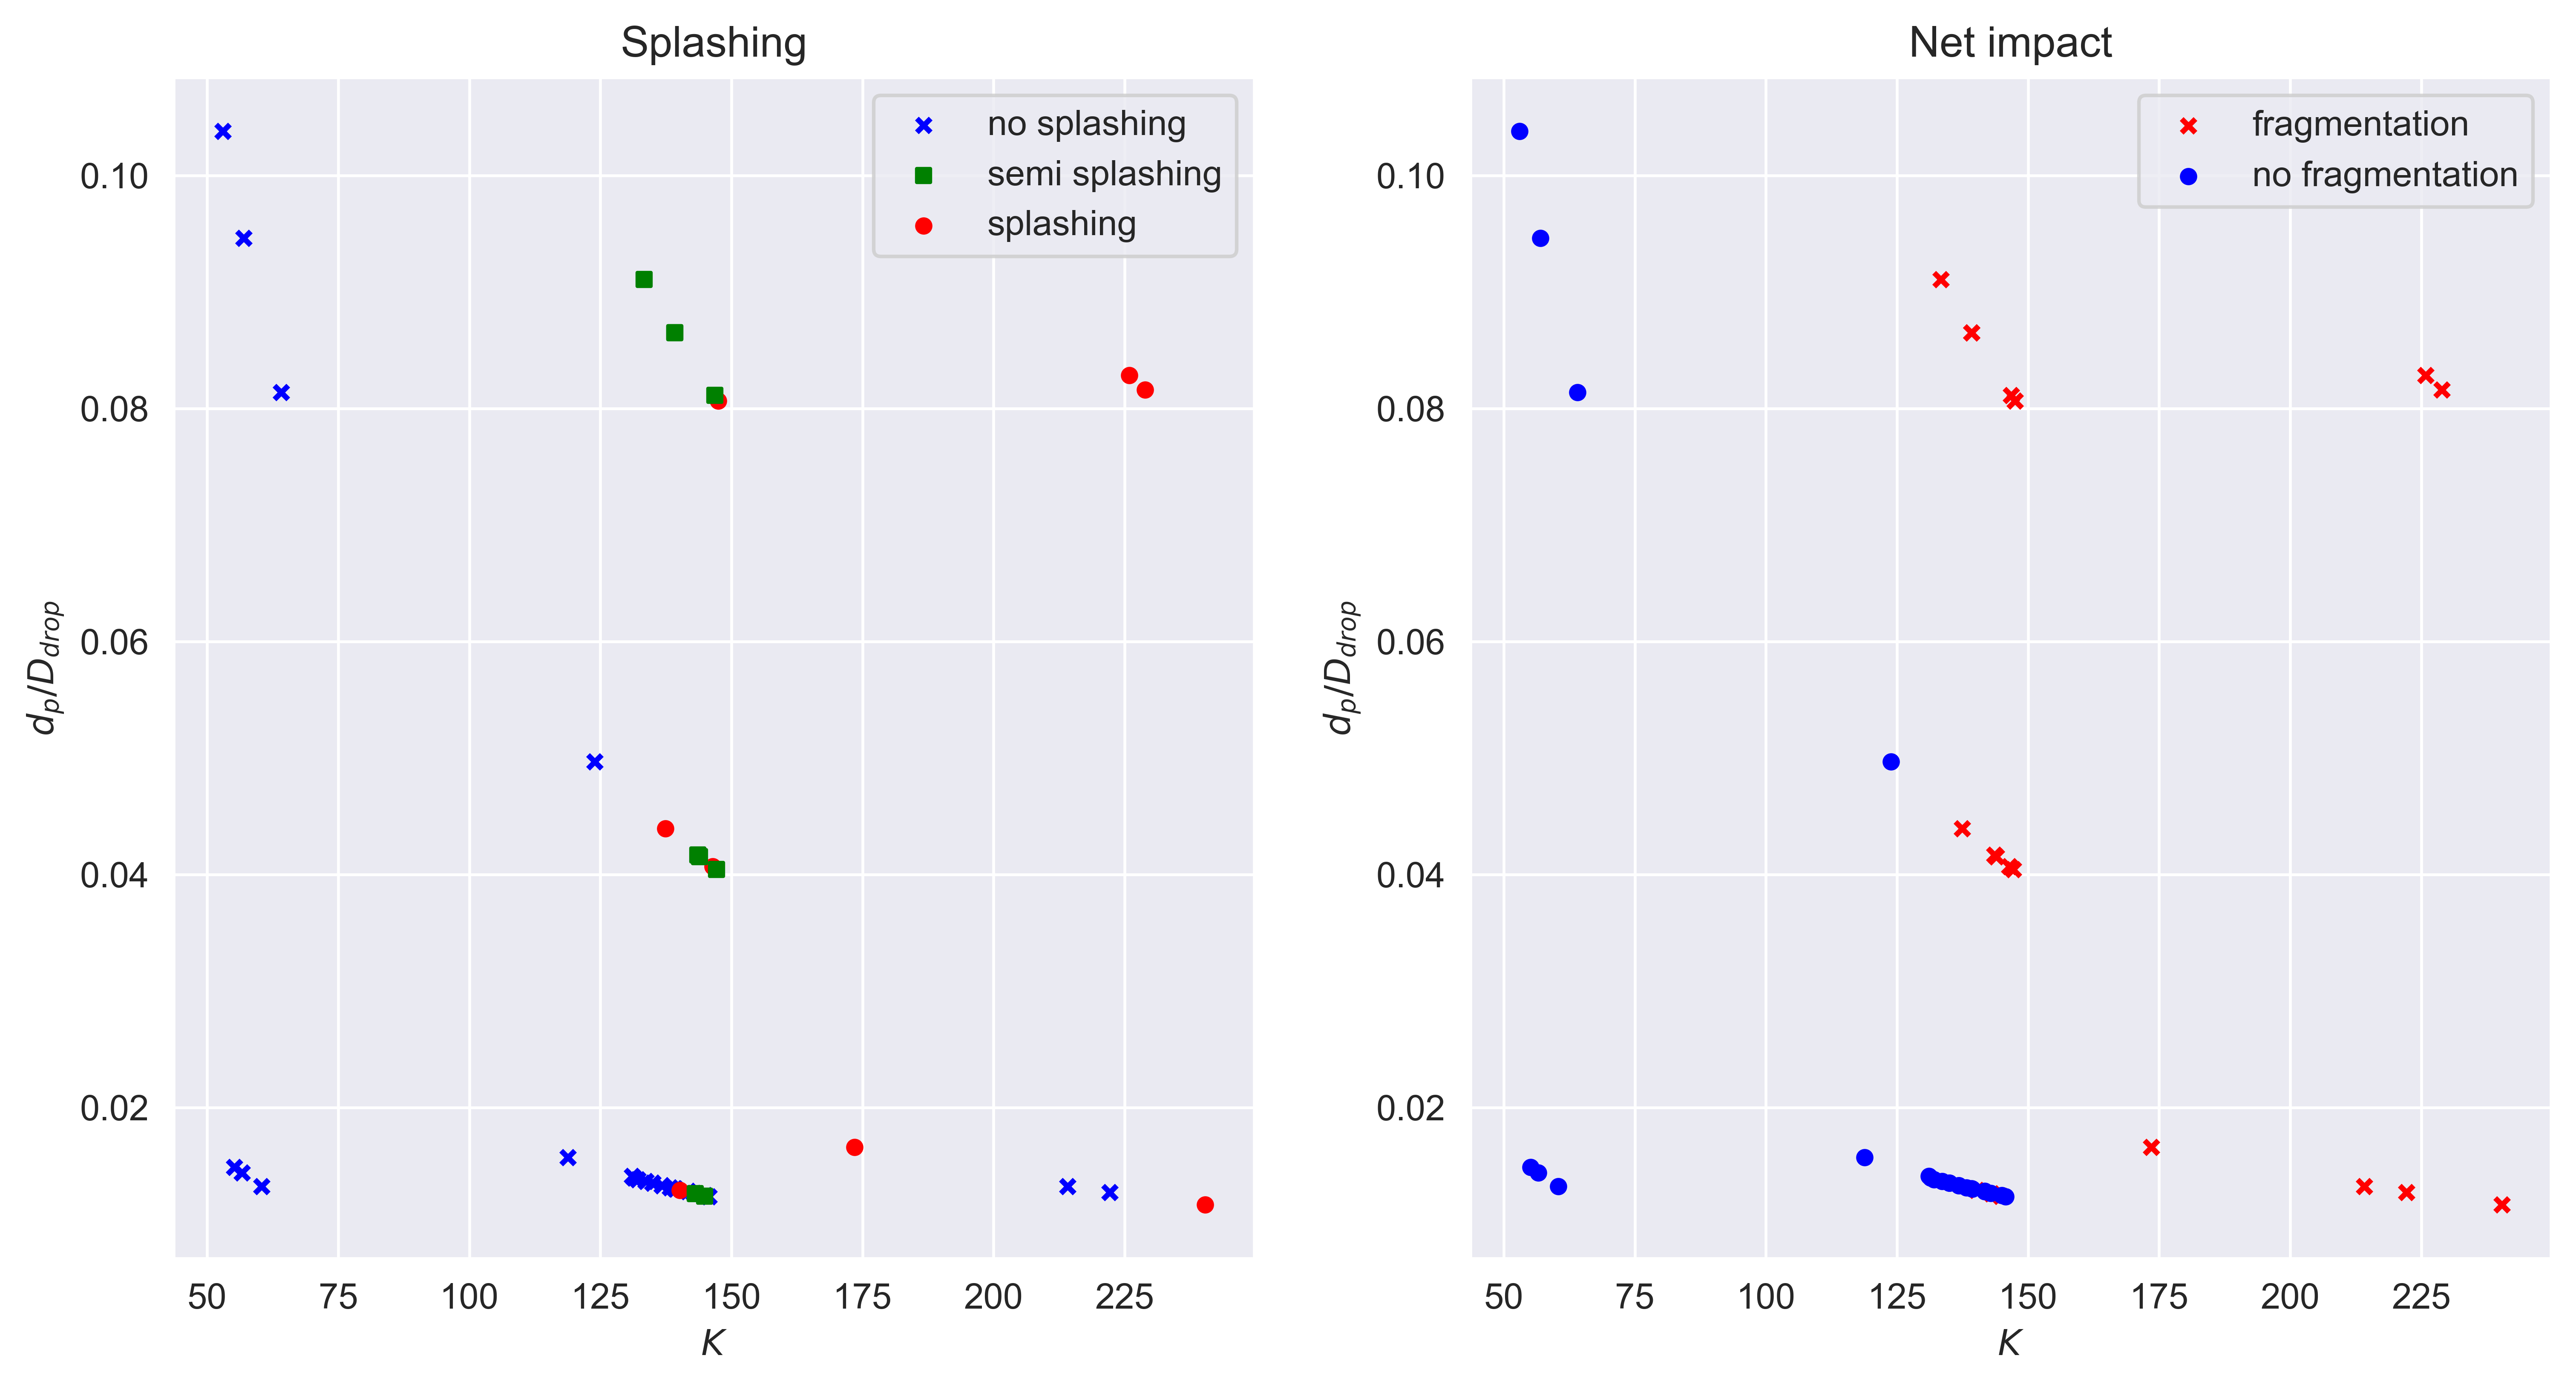

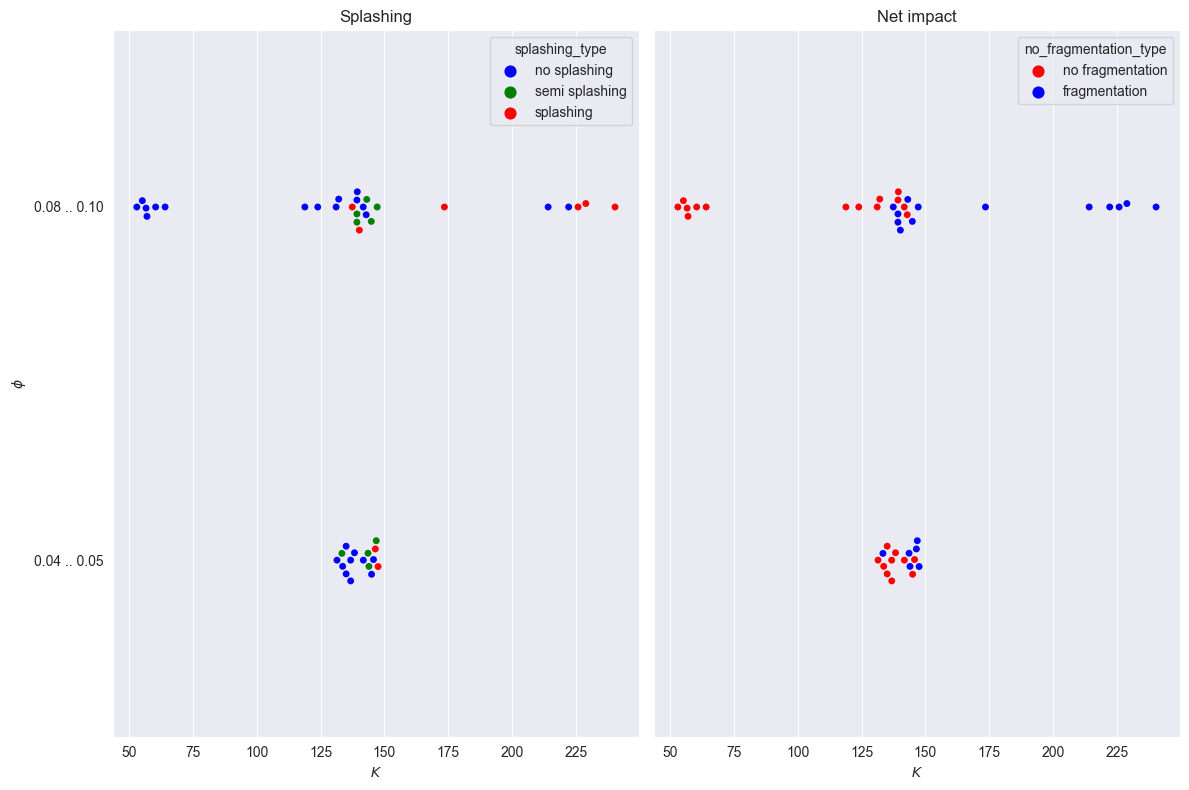

In [47]:
plot_scatters(glycerol_df)

Let us check no splashing cases

In [48]:
glycerol_df[(glycerol_df['splashing'] == 0) & (glycerol_df['K']>200)].T

,327,328
test,351,352
no_fragmentation,0,0
splashing,0,0
splashing_spectrum,0,0
breaking_up,1,1
rebound,0,0
wettability,lyophilic,lyophilic
roughness,0.1,0.1
liquid_density,1180,1180
surface_tension,0.0679,0.0679


Both tests were checked twice. There are no splashing and gears..

Test 351

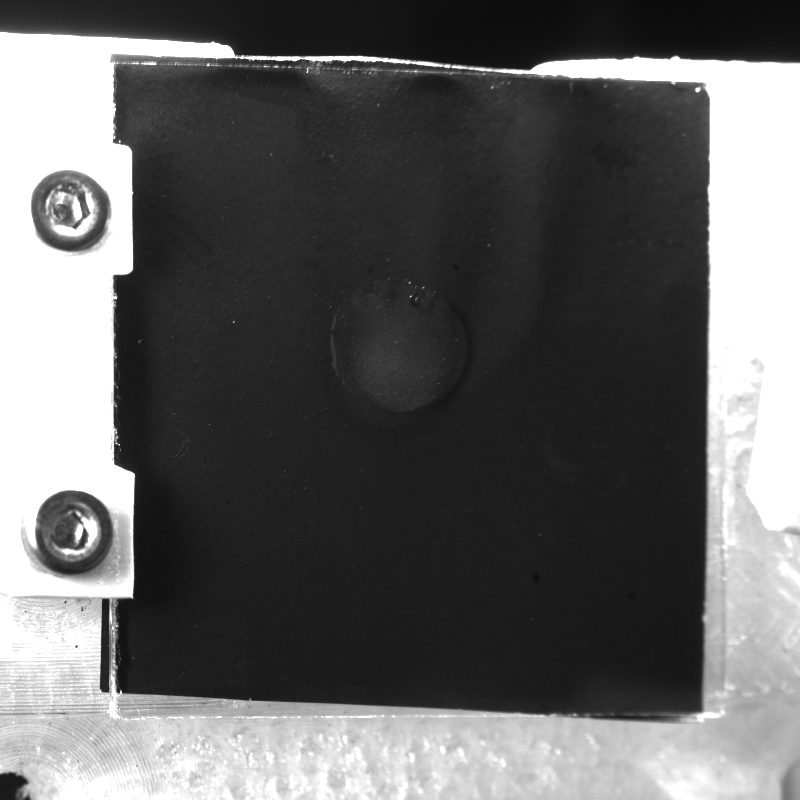

Test 352

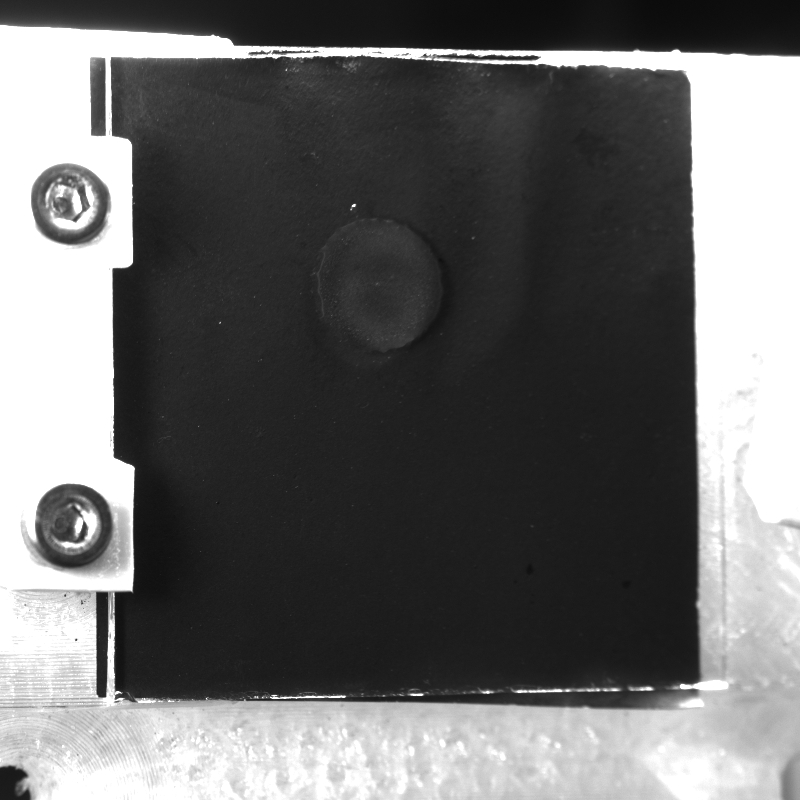